# About Project
#### Description:
This project was made in 03/2026 for the makerhub final project of Technobel training as Data analyst.
This ML part was the end of a whole project analyzing Chess games results.

The goal here is to recover a large dataset created by the data collection python files (5months of games) and to create a ML model tht will be saved in order to use it for further applications




In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from tqdm import tqdm
import os
import joblib

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,RandomizedSearchCV,learning_curve,validation_curve,GridSearchCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, roc_auc_score, make_scorer
from sklearn.base import BaseEstimator, ClassifierMixin

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization,Input
from tensorflow.keras.models import Sequential,load_model
from scikeras.wrappers import KerasClassifier


# Data Collection

In [149]:
dfchesscom = pd.read_csv("./df_chesscom.csv")
dflichess = pd.read_csv("./df_lichess.csv")
dftwic = pd.read_csv("./Parties_twic.csv")
dftwic.head()

,Player white,Player black,Result white,Result black,Date partie,Heure partie,ELO white,ELO black,Opening,Code Opening,Rated,Time control,Type de partie,Liste des coups
0,"Predke,A","Maurizzi,MarcAndria",Draw,Draw,2025-10-07,NaN,2634,2624,Ruy Lopez,C65,NaN,Unknown,classical,NaN
1,"Fressinet,L","Sarana,A",Draw,Draw,2025-10-07,NaN,2602,2661,QGD,D38,NaN,Unknown,classical,NaN
2,"Indjic,A","Lagarde,Max",Win,Loss,2025-10-07,NaN,2618,2617,English,A37,NaN,Unknown,classical,NaN
3,"Boyer,Mahel","Ivic,Velimir",Draw,Draw,2025-10-07,NaN,2532,2628,Reti,A07,NaN,Unknown,classical,NaN
4,"Fedoseev,Vl3","Theodorou,Nikolas",Draw,Draw,2025-10-07,NaN,2720,2652,King's Indian,E92,NaN,Unknown,classical,NaN


In [150]:
dfchesscom['Source'] = "chesscom"
dflichess['Source1'] = "lichess"
dftwic['Source2'] = "twic"

In [151]:
dfchesscom.head()

,Unnamed: 0,Player white,Player black,Result white,Result black,Date partie,Heure partie,ELO white,ELO black,Opening,Code Opening,Rated,Time control,Type de partie,Liste des coups,Source
0,0,Cripep,reflections207,win,resigned,2025-09-25,14:50:15,2363,1546,Kings-Gambit-Accepted-Fischer-Defense-4.d4-g5-...,C34,True,1/432000,daily,\n1. e4 {[%clk 0:00:01.2]} 1... e5 {[%clk 0:00...,chesscom
1,1,reflections207,Cripep,resigned,win,2025-10-02,04:52:16,1561,2365,Reti-Opening-Dutch-Variation...5.d4-O-O-6.b3-d...,A04,True,1/432000,daily,\n1. d4 {[%clk 0:38:03.8]} 1... f5 {[%clk 1:30...,chesscom
2,2,Cripep,reflections207,win,resigned,2025-10-29,18:10:14,2367,1563,Kings-Gambit-Accepted-Bishops-Gambit-Cozio-Var...,C33,True,1/432000,daily,\n1. e4 {[%clk 0:06:07.7]} 1... e5 {[%clk 0:00...,chesscom
3,3,reflections207,Cripep,resigned,win,2025-11-03,21:07:44,1562,2369,Kings-Indian-Defense-Fianchetto-Debrecen-Class...,E68,True,1/432000,daily,\n1. d4 {[%clk 0:00:25.5]} 1... Nf6 {[%clk 0:0...,chesscom
4,4,Cripep,reflections207,win,resigned,2025-11-09,20:53:47,2371,1570,Kings-Gambit-Accepted-Fischer-Defense-4.d4-g5-...,C34,True,1/432000,daily,\n1. e4 {[%clk 0:00:00.6]} 1... e5 {[%clk 0:03...,chesscom


In [152]:
dfchesscom.drop(columns=['Unnamed: 0','Date partie','Heure partie','Opening','Rated','Time control','Liste des coups'],inplace=True)
dfchesscom.head()

,Player white,Player black,Result white,Result black,ELO white,ELO black,Code Opening,Type de partie,Source
0,Cripep,reflections207,win,resigned,2363,1546,C34,daily,chesscom
1,reflections207,Cripep,resigned,win,1561,2365,A04,daily,chesscom
2,Cripep,reflections207,win,resigned,2367,1563,C33,daily,chesscom
3,reflections207,Cripep,resigned,win,1562,2369,E68,daily,chesscom
4,Cripep,reflections207,win,resigned,2371,1570,C34,daily,chesscom


In [153]:
dflichess.head()

,Unnamed: 0,Player white,Player black,Result white,Result black,Date partie,Heure partie,ELO white,ELO black,Opening,Code Opening,Rated,Time control,Type de partie,Liste des coups,Source1
0,0,Yarebore,HardWork1996,win,resigned,2026-03-03,NaN,3006,2649,Zukertort Opening,A06,True,180,blitz,Nf3 d5 e3 Nf6 c4 e6 Nc3 b6 cxd5 exd5 g3 Bb7 Bg...,lichess
1,1,HardWork1996,Yarebore,resigned,win,2026-03-03,NaN,2650,3003,Modern Defense: Standard Line,B06,True,180,blitz,e4 g6 d4 Bg7 Nc3 a6 h4 b5 h5 Bb7 f3 d6 Be3 Nd7...,lichess
2,2,Aktinia22,Yarebore,resigned,win,2026-02-20,NaN,2679,3000,Rapport-Jobava System,D01,True,180,blitz,d4 Nf6 Nc3 e6 Bf4 d5 e3 Bd6 Qf3 Nc6 g4 e5 Bg5 ...,lichess
3,3,Yarebore,chris_hamburger,win,resigned,2026-02-16,NaN,3000,1500,Italian Game: Giuoco Pianissimo,C50,False,300,blitz,e4 e5 Nf3 Nc6 Nc3 Nf6 Bc4 Bc5 d3 d6 O-O O-O Bg...,lichess
4,4,chris_hamburger,Yarebore,draw,draw,2026-02-16,NaN,1500,3000,Italian Game: Giuoco Piano,C50,False,300,blitz,e4 e5 Nf3 Nc6 Bc4 Bc5 O-O Nf6 d3 O-O Bg5 h6 Bh...,lichess


In [154]:
dflichess.drop(columns=['Unnamed: 0','Date partie','Heure partie','Opening','Rated','Time control','Liste des coups'],inplace=True)
dflichess.head()

,Player white,Player black,Result white,Result black,ELO white,ELO black,Code Opening,Type de partie,Source1
0,Yarebore,HardWork1996,win,resigned,3006,2649,A06,blitz,lichess
1,HardWork1996,Yarebore,resigned,win,2650,3003,B06,blitz,lichess
2,Aktinia22,Yarebore,resigned,win,2679,3000,D01,blitz,lichess
3,Yarebore,chris_hamburger,win,resigned,3000,1500,C50,blitz,lichess
4,chris_hamburger,Yarebore,draw,draw,1500,3000,C50,blitz,lichess


In [155]:
dftwic.tail()


,Player white,Player black,Result white,Result black,Date partie,Heure partie,ELO white,ELO black,Opening,Code Opening,Rated,Time control,Type de partie,Liste des coups,Source2
137497,"Javakhadze,Z","Rustemov,A",Win,Loss,2026-02-26,NaN,2417,2525,Reti,A07,NaN,Unknown,classical,NaN,twic
137498,"Ermolaev,An","Khanbutaev,Artemii",Draw,Draw,2026-02-26,NaN,2274,2135,Queen's pawn game,A45,NaN,Unknown,classical,NaN,twic
137499,"Yin,Evan","Lopez Fuentes,Wilberth Sebastian",Win,Loss,2026-02-26,NaN,2098,2030,Four knights,C48,NaN,Unknown,classical,NaN,twic
137500,"Tan,Jun Ying","Fus,Jakub",Loss,Win,2026-02-26,NaN,2404,2423,English,A14,NaN,Unknown,classical,NaN,twic
137501,"Erigaisi,Arjun","Cahaya,Satria Duta",Win,Loss,2026-02-26,NaN,2775,2394,Reti,A09,NaN,Unknown,classical,NaN,twic


In [156]:
dftwic.drop(columns=['Heure partie','Opening','Rated','Time control','Liste des coups'],inplace=True)
dftwic.head()

,Player white,Player black,Result white,Result black,Date partie,ELO white,ELO black,Code Opening,Type de partie,Source2
0,"Predke,A","Maurizzi,MarcAndria",Draw,Draw,2025-10-07,2634,2624,C65,classical,twic
1,"Fressinet,L","Sarana,A",Draw,Draw,2025-10-07,2602,2661,D38,classical,twic
2,"Indjic,A","Lagarde,Max",Win,Loss,2025-10-07,2618,2617,A37,classical,twic
3,"Boyer,Mahel","Ivic,Velimir",Draw,Draw,2025-10-07,2532,2628,A07,classical,twic
4,"Fedoseev,Vl3","Theodorou,Nikolas",Draw,Draw,2025-10-07,2720,2652,E92,classical,twic


In [157]:
#concatenation
dfParties = pd.concat([dftwic,dfchesscom,dflichess])
dfParties.head()


,Player white,Player black,Result white,Result black,Date partie,ELO white,ELO black,Code Opening,Type de partie,Source2,Source,Source1
0,"Predke,A","Maurizzi,MarcAndria",Draw,Draw,2025-10-07,2634,2624,C65,classical,twic,NaN,NaN
1,"Fressinet,L","Sarana,A",Draw,Draw,2025-10-07,2602,2661,D38,classical,twic,NaN,NaN
2,"Indjic,A","Lagarde,Max",Win,Loss,2025-10-07,2618,2617,A37,classical,twic,NaN,NaN
3,"Boyer,Mahel","Ivic,Velimir",Draw,Draw,2025-10-07,2532,2628,A07,classical,twic,NaN,NaN
4,"Fedoseev,Vl3","Theodorou,Nikolas",Draw,Draw,2025-10-07,2720,2652,E92,classical,twic,NaN,NaN


In [158]:
dfParties.head()

,Player white,Player black,Result white,Result black,Date partie,ELO white,ELO black,Code Opening,Type de partie,Source2,Source,Source1
0,"Predke,A","Maurizzi,MarcAndria",Draw,Draw,2025-10-07,2634,2624,C65,classical,twic,NaN,NaN
1,"Fressinet,L","Sarana,A",Draw,Draw,2025-10-07,2602,2661,D38,classical,twic,NaN,NaN
2,"Indjic,A","Lagarde,Max",Win,Loss,2025-10-07,2618,2617,A37,classical,twic,NaN,NaN
3,"Boyer,Mahel","Ivic,Velimir",Draw,Draw,2025-10-07,2532,2628,A07,classical,twic,NaN,NaN
4,"Fedoseev,Vl3","Theodorou,Nikolas",Draw,Draw,2025-10-07,2720,2652,E92,classical,twic,NaN,NaN


In [159]:
#Gérer la source
def handle_source(row):
    
    if row['Source2'] is not np.nan:
        return row['Source2']
    elif row['Source'] is not np.nan:
        return row['Source']
    else:
        return row['Source1']

dfParties['Platform'] = dfParties.apply(handle_source,axis=1)
dfParties.drop(columns=['Source2','Source','Source1'],inplace=True)
dfParties.head()

,Player white,Player black,Result white,Result black,Date partie,ELO white,ELO black,Code Opening,Type de partie,Platform
0,"Predke,A","Maurizzi,MarcAndria",Draw,Draw,2025-10-07,2634,2624,C65,classical,twic
1,"Fressinet,L","Sarana,A",Draw,Draw,2025-10-07,2602,2661,D38,classical,twic
2,"Indjic,A","Lagarde,Max",Win,Loss,2025-10-07,2618,2617,A37,classical,twic
3,"Boyer,Mahel","Ivic,Velimir",Draw,Draw,2025-10-07,2532,2628,A07,classical,twic
4,"Fedoseev,Vl3","Theodorou,Nikolas",Draw,Draw,2025-10-07,2720,2652,E92,classical,twic


# Datas infos

In [160]:
display(dfParties.describe())
display(dfParties.info())
display(dfParties.isnull().sum())

,Player white,Player black,Result white,Result black,Date partie,ELO white,ELO black,Code Opening,Type de partie,Platform
count,429397,429397,429397,429397,137502,429397,429397,429397,429397,429397
unique,37082,36898,15,15,206,4065,4050,500,5,3
top,tactic,tactic,win,win,2025-12-29,Unknown,Unknown,A00,bullet,chesscom
freq,5770,5784,141077,129076,3007,1432,1476,17602,154917,175873


<class 'pandas.core.frame.DataFrame'>
Index: 429397 entries, 0 to 116021
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Player white    429397 non-null  object
 1   Player black    429397 non-null  object
 2   Result white    429397 non-null  object
 3   Result black    429397 non-null  object
 4   Date partie     137502 non-null  object
 5   ELO white       429397 non-null  object
 6   ELO black       429397 non-null  object
 7   Code Opening    429397 non-null  object
 8   Type de partie  429397 non-null  object
 9   Platform        429397 non-null  object
dtypes: object(10)
memory usage: 36.0+ MB


None

Player white           0
Player black           0
Result white           0
Result black           0
Date partie       291895
ELO white              0
ELO black              0
Code Opening           0
Type de partie         0
Platform               0
dtype: int64

# Datas cleaning

In [161]:
#Supprimer les lignes ou ELO est 'unknown'
dfParties= dfParties[
    (dfParties['Result black'] != 'Unknown') & 
    (dfParties['Result white'] != 'Unknown') &
    (dfParties['ELO white'] != 'Unknown') &
    (dfParties['ELO black'] != 'Unknown') 
    ].copy()

In [162]:
# Pas besoin de l'ouverture car on ne sait pas à l'avance quelle ouverture sera utilisé (point d'amelioration)

dfParties.drop(columns=['Code Opening'],inplace=True)

In [163]:
dfParties['Date partie'] = dfParties['Date partie'].astype(str)

In [164]:
def handle_date(row):
    date = row["Date partie"]
    
    if date == "????-??-??":
        return "1980-01-01"
    if len(date) < 10:
       
        return "1980-01-01"
    
    return date
dfParties['Date partie'] = dfParties.apply(handle_date,axis=1)

In [165]:
#assurer le typage
dfParties['Player white']=dfParties['Player white'].astype(str)
dfParties['Player black']=dfParties['Player black'].astype(str)
dfParties['Result white']=dfParties['Result white'].astype(str)
dfParties['Result black']=dfParties['Result black'].astype(str)
dfParties['ELO white']=dfParties['ELO white'].astype(int)
dfParties['ELO black']=dfParties['ELO black'].astype(int)
dfParties['Type de partie']=dfParties['Type de partie'].astype(str)
dfParties['Platform']=dfParties['Platform'].astype(str)
dfParties['Date partie'] = dfParties['Date partie'].astype('datetime64[ns]')

# Feature engineering

## Diff Elo

In [166]:
# Creationg de Diff ELO

dfParties['Diff ELO'] = dfParties['ELO white'] - dfParties['ELO black']
dfParties.head()

,Player white,Player black,Result white,Result black,Date partie,ELO white,ELO black,Type de partie,Platform,Diff ELO
0,"Predke,A","Maurizzi,MarcAndria",Draw,Draw,2025-10-07,2634,2624,classical,twic,10
1,"Fressinet,L","Sarana,A",Draw,Draw,2025-10-07,2602,2661,classical,twic,-59
2,"Indjic,A","Lagarde,Max",Win,Loss,2025-10-07,2618,2617,classical,twic,1
3,"Boyer,Mahel","Ivic,Velimir",Draw,Draw,2025-10-07,2532,2628,classical,twic,-96
4,"Fedoseev,Vl3","Theodorou,Nikolas",Draw,Draw,2025-10-07,2720,2652,classical,twic,68


## Winner

In [167]:
dfParties= dfParties[
    (dfParties['Result black'] != 'Unknown') & 
    (dfParties['Result white'] != 'Unknown')
    ]  

In [168]:
# Dictionnaire de mapping
result_mapping = {
        # Victoires
        'win': 'Win',
        'Win': 'Win',
        
        # Défaites
        'Loss': 'Loss',
        'resigned': 'Loss',
        'checkmated': 'Loss',
        'timeout': 'Loss',
        'abandoned': 'Loss',
        
        # Nuls
        'draw': 'Draw',
        'Draw': 'Draw',
        'stalemate': 'Draw',
        'insufficient': 'Draw',
        'timevsinsufficient': 'Draw',
        'repetition': 'Draw',
        'agreed': 'Draw',
        '50move': 'Draw',
        

    }
# Application du mapping
dfParties['Result black'] = dfParties['Result black'].map(result_mapping)
dfParties['Result white'] = dfParties['Result white'].map(result_mapping)

In [169]:
# Creating result global

def find_res(row):
    if row['Result white']== 'Win':
        return "Blanc"
    elif row['Result white']== 'Loss':
        return "Noir"
    else :
        return "Draw"

dfParties['Winner'] = dfParties.apply(find_res,axis=1)
dfParties.head()

,Player white,Player black,Result white,Result black,Date partie,ELO white,ELO black,Type de partie,Platform,Diff ELO,Winner
0,"Predke,A","Maurizzi,MarcAndria",Draw,Draw,2025-10-07,2634,2624,classical,twic,10,Draw
1,"Fressinet,L","Sarana,A",Draw,Draw,2025-10-07,2602,2661,classical,twic,-59,Draw
2,"Indjic,A","Lagarde,Max",Win,Loss,2025-10-07,2618,2617,classical,twic,1,Blanc
3,"Boyer,Mahel","Ivic,Velimir",Draw,Draw,2025-10-07,2532,2628,classical,twic,-96,Draw
4,"Fedoseev,Vl3","Theodorou,Nikolas",Draw,Draw,2025-10-07,2720,2652,classical,twic,68,Draw


In [170]:
#plus besoin des colonnes resultat white et resultat blanc
dfParties.drop(columns=["Result white","Result black"],inplace=True)
dfParties.head()

,Player white,Player black,Date partie,ELO white,ELO black,Type de partie,Platform,Diff ELO,Winner
0,"Predke,A","Maurizzi,MarcAndria",2025-10-07,2634,2624,classical,twic,10,Draw
1,"Fressinet,L","Sarana,A",2025-10-07,2602,2661,classical,twic,-59,Draw
2,"Indjic,A","Lagarde,Max",2025-10-07,2618,2617,classical,twic,1,Blanc
3,"Boyer,Mahel","Ivic,Velimir",2025-10-07,2532,2628,classical,twic,-96,Draw
4,"Fedoseev,Vl3","Theodorou,Nikolas",2025-10-07,2720,2652,classical,twic,68,Draw


In [171]:
# Dictionnaire de mapping
type_partie_mapping = {
        
        'daily': 'classical', 
        'bullet' : 'bullet',
        'blitz' : 'blitz',
        'rapid':'rapid',
        'classical' : 'classical'

    }

# Application du mapping
dfParties['Type de partie'] = dfParties['Type de partie'].map(type_partie_mapping)

In [172]:
# Supprimer les lignes où il y a Unknown dans ELO white, ELO black, Opening ou Code Opening
dfParties = dfParties[
        (dfParties['ELO white'] != 'Unknown') & 
        (dfParties['ELO black'] != 'Unknown') 
        
    
    ].copy()

## Nombre parties joueur blanc, noir

In [173]:
import pandas as pd
from tqdm import tqdm

def compute_games_played(df):
    df = df.sort_values("Date partie").reset_index(drop=True) # on trie par Date 
    
    games_count = {}
    nb_blanc = []
    nb_noir = []
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Calcul parties jouées", unit="partie"): #tqdm = etatt d'vancement
        white = row["Player white"]
        black = row["Player black"]
        
        #Recupere le joueur dans le dictionnaire si existe , sinon on retourne 0 et ajoute dans l liste qui sera ajouté au df
        nb_blanc.append(games_count.get(white, 0))#games_count : {nom_joueur: nb_parties}
        nb_noir.append(games_count.get(black, 0))

        #+1 au nombre de parties de ce joueur dans le dictionnaire
        games_count[white] = games_count.get(white, 0) + 1 
        games_count[black] = games_count.get(black, 0) + 1
    
    df["Nb_parties_joueur_blanc"] = nb_blanc
    df["Nb_parties_joueur_noir"] = nb_noir
    
    return df

dfParties = compute_games_played(dfParties)
dfParties.head()

Calcul parties jouées: 100%|██████████| 426694/426694 [00:29<00:00, 14546.46partie/s]


,Player white,Player black,Date partie,ELO white,ELO black,Type de partie,Platform,Diff ELO,Winner,Nb_parties_joueur_blanc,Nb_parties_joueur_noir
0,vi_pranav,SuperPower2011,1980-01-01,3123,2969,blitz,chesscom,154,Noir,0,0
1,Swiss_Fighter,JamesBond0200007,1980-01-01,2928,2788,bullet,chesscom,140,Noir,0,0
2,JamesBond0200007,Swiss_Fighter,1980-01-01,2777,2939,bullet,chesscom,-162,Draw,1,1
3,Swiss_Fighter,JamesBond0200007,1980-01-01,2943,2773,bullet,chesscom,170,Blanc,2,2
4,JamesBond0200007,Swiss_Fighter,1980-01-01,2778,2938,bullet,chesscom,-160,Noir,3,3


## Nombre de parties l'un contre l'autre

## Nombre win, draw, loose joueur blanc -> joueur noir

## last 10 games

In [174]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque
from tqdm import tqdm

# ── 0. Pré-requis ─────────────────────────────────────────────────────────────
dfParties = dfParties.sort_values("Date partie").reset_index(drop=True) #trie par date

pw = dfParties["Player white"].values #extrait les datas et trasnforme en nparray
pb = dfParties["Player black"].values
dates = dfParties["Date partie"].values
winner = dfParties["Winner"].values
n = len(dfParties)

# ── 1. Nb_parties_eachother ───────────────────────────────────────────────────
pair_count = defaultdict(int) #C'est un dictionnaire spécial qui crée automatiquement une valeur par défaut quand une clé n'existe pas encore.
nb_games = np.zeros(n, dtype=np.int32)

for i in tqdm(range(n), desc="Nb parties eachother", unit="partie"): #ligne par ligne
    key = (min(pw[i], pb[i]), max(pw[i], pb[i])) # Crée une clé unique(alphabetique) pour la paire de joueurs, indépendamment de qui joue blanc ou noir.
    nb_games[i] = pair_count[key] #Enregistre le nombre de confrontations avant cette partie
    pair_count[key] += 1

dfParties["Nb_parties_eachother"] = nb_games

# ── 2. H2H ────────────────────────────────────────────────────────────────────
h2h_wins   = np.zeros(n, dtype=np.int32)
h2h_draws  = np.zeros(n, dtype=np.int32)
h2h_losses = np.zeros(n, dtype=np.int32)

h2h_store = defaultdict(lambda: [0, 0, 0])

for i in tqdm(range(n), desc="H2H wins/draws/losses", unit="partie"):
    j1, j2, w = pw[i], pb[i], winner[i]
    key_normal  = (j1, j2)
    key_reverse = (j2, j1)

    ww, dd, ll = h2h_store[key_normal]

    if key_reverse in h2h_store:
        rw, rd, rl = h2h_store[key_reverse]
        ww += rl
        dd += rd
        ll += rw

    h2h_wins[i], h2h_draws[i], h2h_losses[i] = ww, dd, ll

    store = h2h_store[key_normal]
    if w == "Blanc":
        store[0] += 1
    elif w == "Draw":
        store[1] += 1
    else:
        store[2] += 1

dfParties["H2H_wins"]   = h2h_wins
dfParties["H2H_draws"]  = h2h_draws
dfParties["H2H_losses"] = h2h_losses

# ── 3. Last-10-games ──────────────────────────────────────────────────────────
l10_blanc = np.zeros(n, dtype=np.int32)
l10_noir  = np.zeros(n, dtype=np.int32)

player_history = defaultdict(lambda: deque(maxlen=10))

for i in tqdm(range(n), desc="Last 10 games", unit="partie"):
    j1, j2, w = pw[i], pb[i], winner[i]

    # Lire AVANT de modifier
    l10_blanc[i] = sum(player_history[j1])
    l10_noir[i]  = sum(player_history[j2])

    # Stocker un booléen : le joueur a-t-il gagné ?
    player_history[j1].append(1 if w == "Blanc" else 0)
    player_history[j2].append(1 if w == "Noir"  else 0)

dfParties["L10g_blanc"] = l10_blanc
dfParties["L10g_noir"]  = l10_noir

Last 10 games: 100%|██████████| 426694/426694 [00:01<00:00, 351219.10partie/s]


In [175]:
dfParties.to_csv("./ML4.csv")

PermissionError: [Errno 13] Permission denied: './ML4.csv'

# Deep Analysis
## Features visu

In [ ]:
dfParties.tail()

,Player white,Player black,Date partie,ELO white,ELO black,Type de partie,Platform,Diff ELO,Winner,Nb_parties_joueur_blanc,Nb_parties_joueur_noir,Nb_parties_eachother,H2H_wins,H2H_draws,H2H_losses,L10g_blanc,L10g_noir
426689,"Grischuk,A","Tsaruk,Maksim",2026-03-02,2645,2507,classical,twic,138,Blanc,341,205,1,0,0,1,7,7
426690,"Khismatullin,D","Esipenko,Andrey",2026-03-02,2532,2698,classical,twic,-166,Noir,51,232,0,0,0,0,4,7
426691,"Nikitenko,M","Bardyk,Artem",2026-03-02,2486,2390,classical,twic,96,Draw,81,129,0,0,0,0,2,4
426692,"Daneshvar,Bardiya","Nurgaliyev,Sauat",2026-03-02,2597,2423,classical,twic,174,Draw,131,94,0,0,0,0,6,6
426693,"Drygalov,Sergey","Yeletsky,Ivan",2026-03-02,2571,2421,classical,twic,150,Draw,216,85,0,0,0,0,6,7


In [ ]:
df_features = dfParties.drop(['Winner'],axis=1)
df_target = dfParties['Winner']

# Séparer les colonnes numériques
numeric_df = dfParties.select_dtypes(include=['number'])

# Séparer les colonnes catégorielles (objets/strings)
categorical_df = dfParties.select_dtypes(exclude=['number'])

100 3600
100 3654
-3114 3049
0 11553
0 11550
0 1093
0 622
0 42
0 625
0 10
0 10


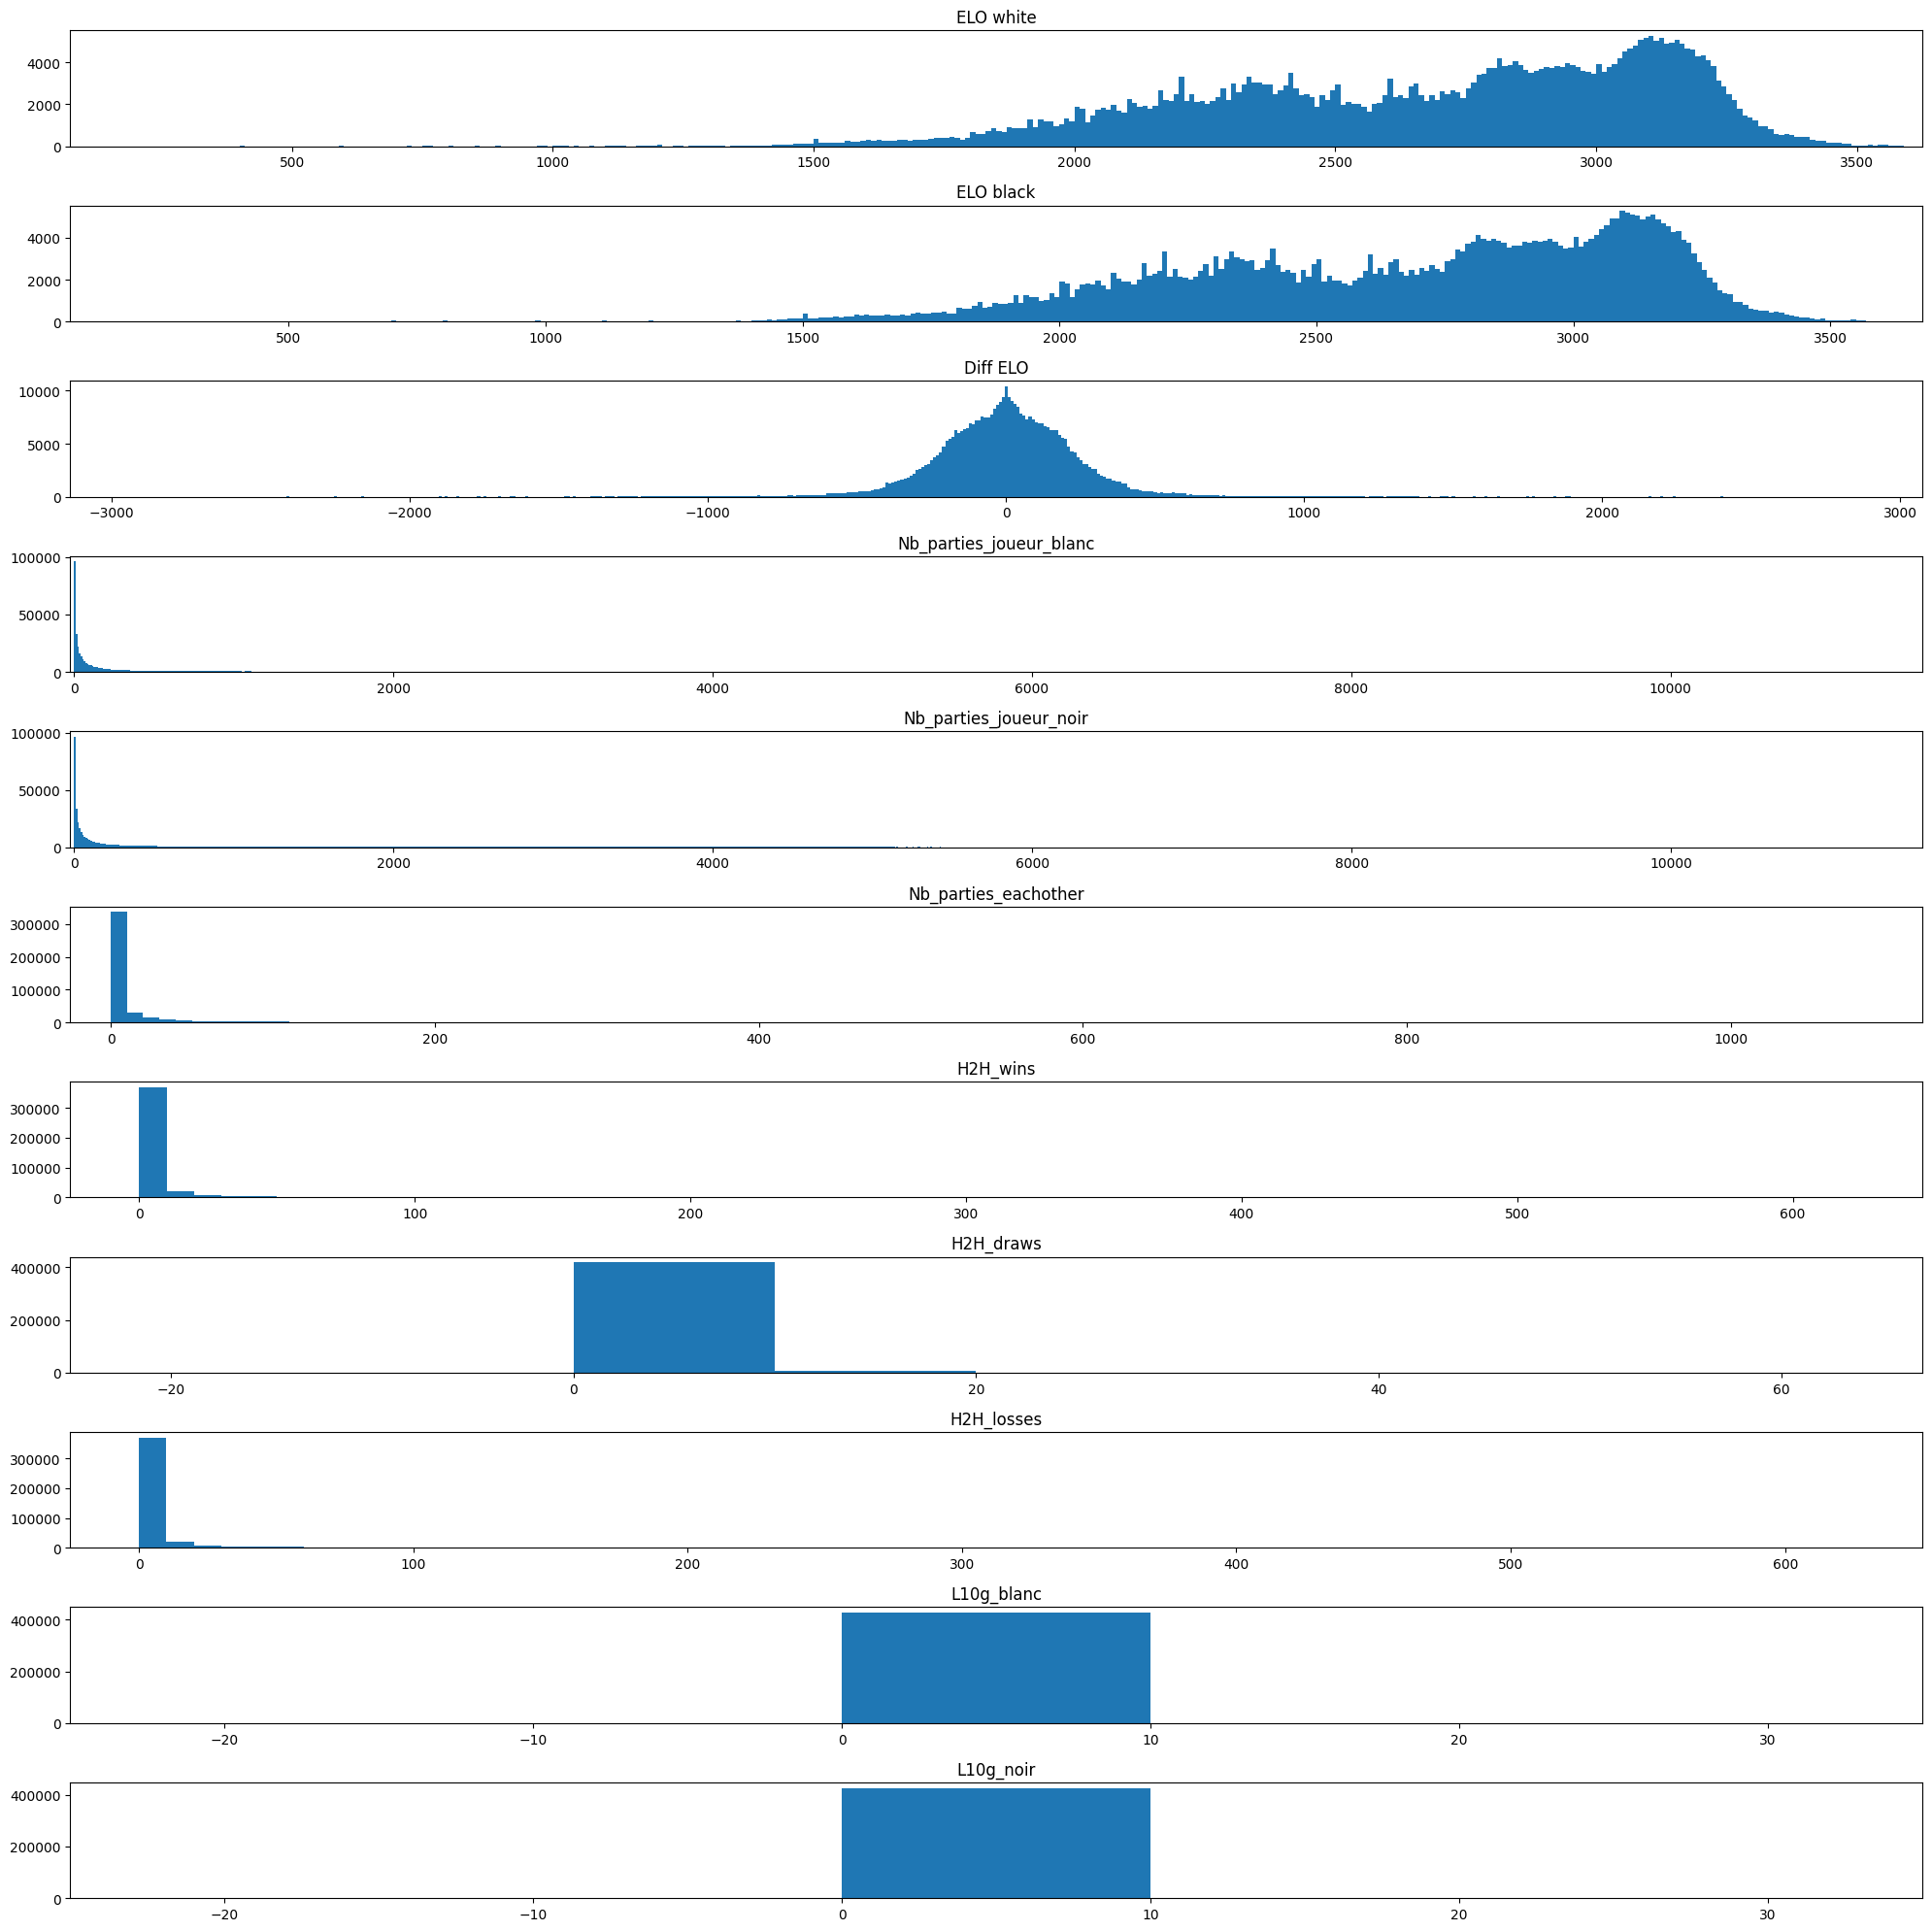

In [ ]:
fig,axs = plt.subplots(11,1,figsize=(20,20))

for i in range (0,numeric_df.shape[1]): 
    # Calculate bins with width : 25
    min_val = numeric_df.iloc[:, i].min()
    max_val = numeric_df.iloc[:, i].max()
    bins = np.arange(min_val, max_val + 10, 10)
    print(min_val,max_val)
    axs[i].hist(numeric_df.iloc[:, i], bins=bins)
    axs[i].set_title(numeric_df.columns[i])
    axs[i].set_xlim(min_val-25, max_val +25)  # Limit x axis
    

plt.tight_layout()
plt.show()

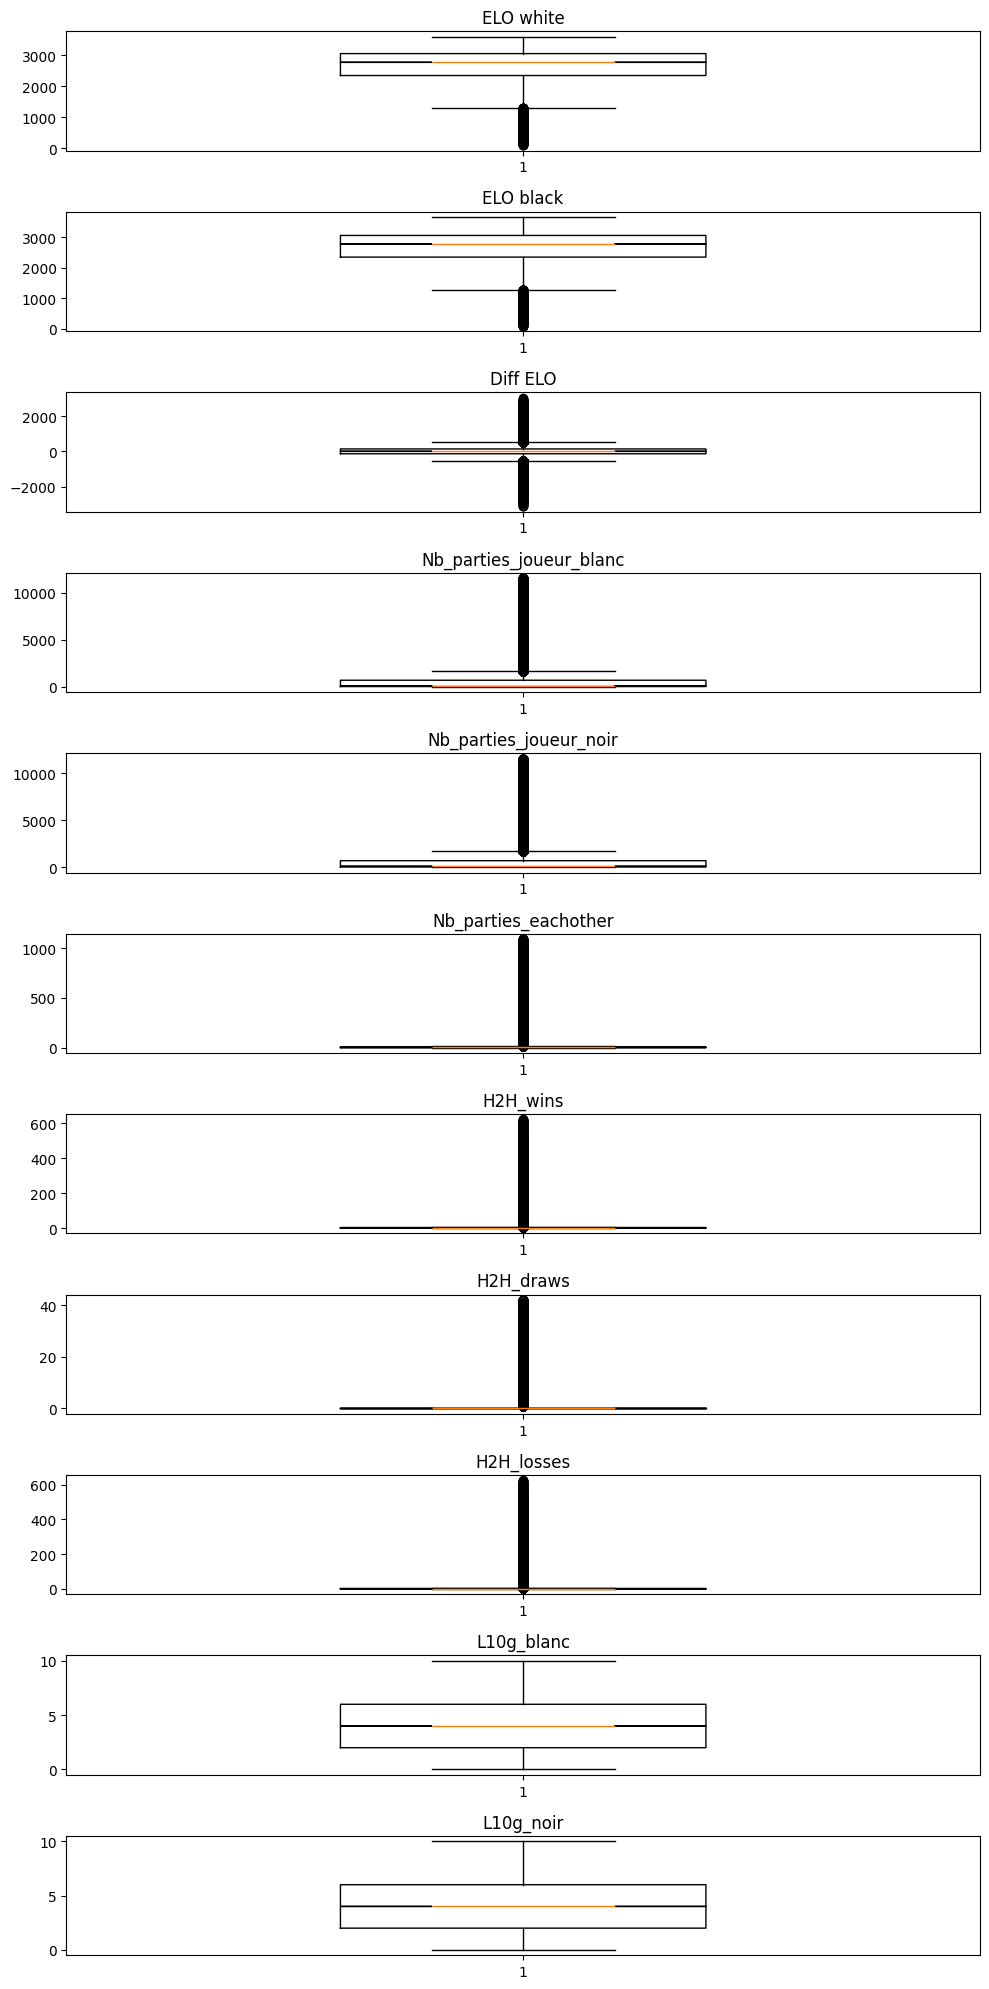

In [ ]:
fig,axs = plt.subplots(11,1,figsize=(10,20))

for i in range (0,numeric_df.shape[1]):

    axs[i].boxplot(numeric_df.iloc[:,i],notch=True,widths = 0.4)
    axs[i].set_title(numeric_df.columns[i])

plt.tight_layout()
plt.show()

## Target visu

In [ ]:
df_target.unique()

array(['Noir', 'Blanc', 'Draw'], dtype=object)

## Target/features relations

In [ ]:
#on va devoir maper la colonne result pour ca
maping = {'Blanc':1,'Noir':-1,'Draw':0}
df_target = df_target.map(maping)


In [ ]:
df_features.drop(columns=['Player white','Player black'],inplace=True)
df_features.drop(columns=['Date partie'],inplace=True)
df_cols = df_features.columns.tolist()

In [ ]:
df_target.head()

0   -1
1    1
2    1
3   -1
4    1
Name: Winner, dtype: int64

In [ ]:
df_cols

['ELO white',
 'ELO black',
 'Type de partie',
 'Platform',
 'Diff ELO',
 'Nb_parties_joueur_blanc',
 'Nb_parties_joueur_noir',
 'Nb_parties_eachother',
 'H2H_wins',
 'H2H_draws',
 'H2H_losses',
 'L10g_blanc',
 'L10g_noir']

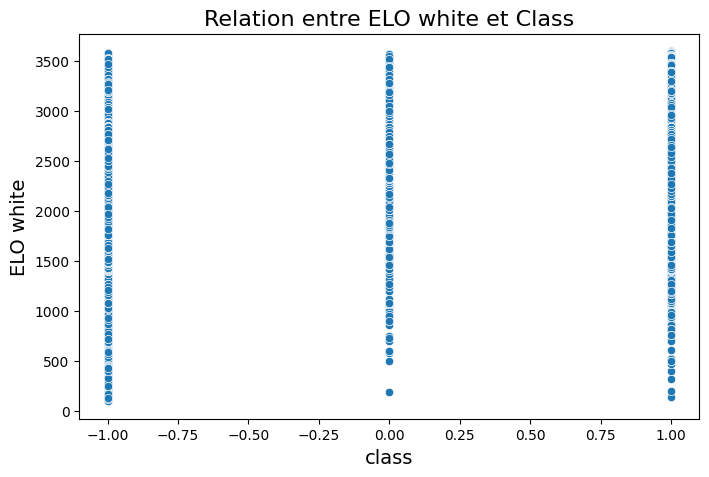

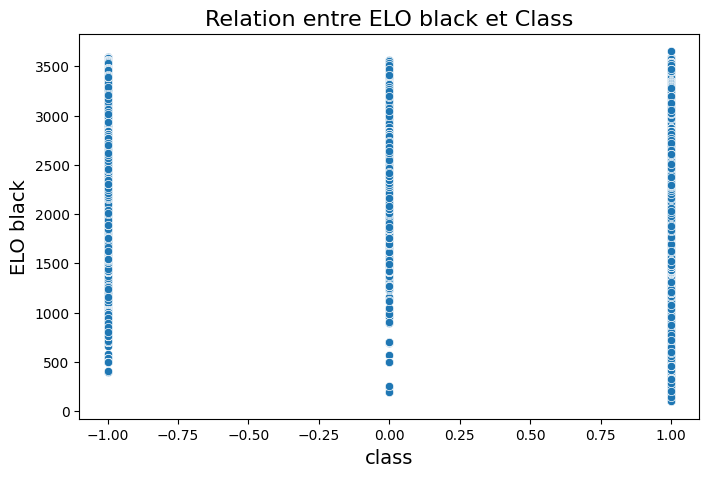

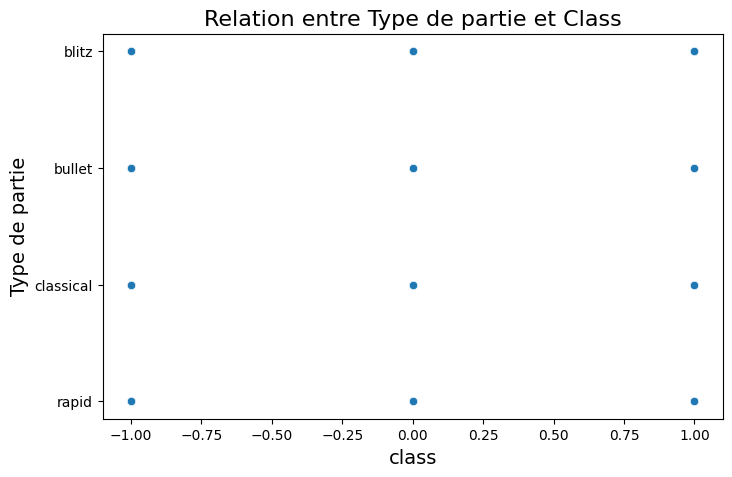

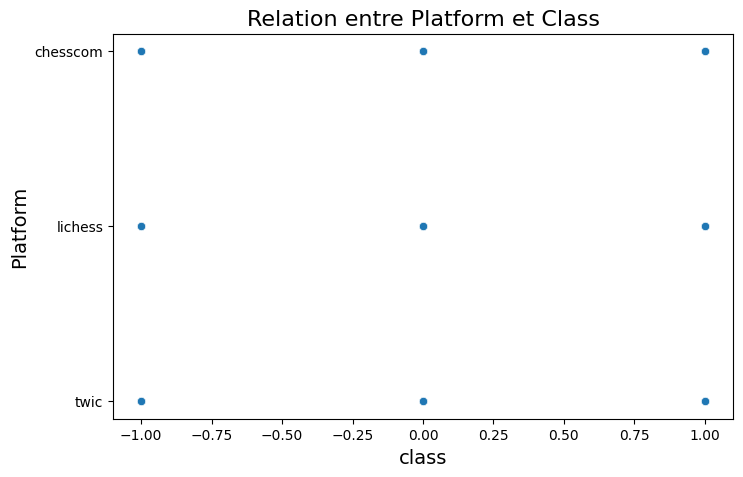

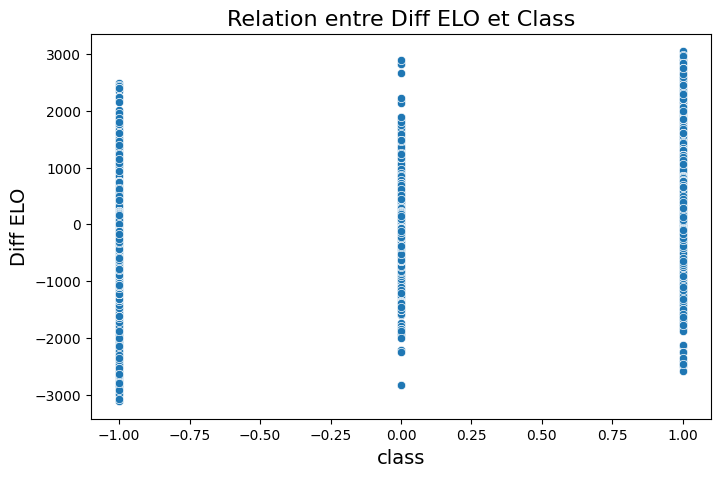

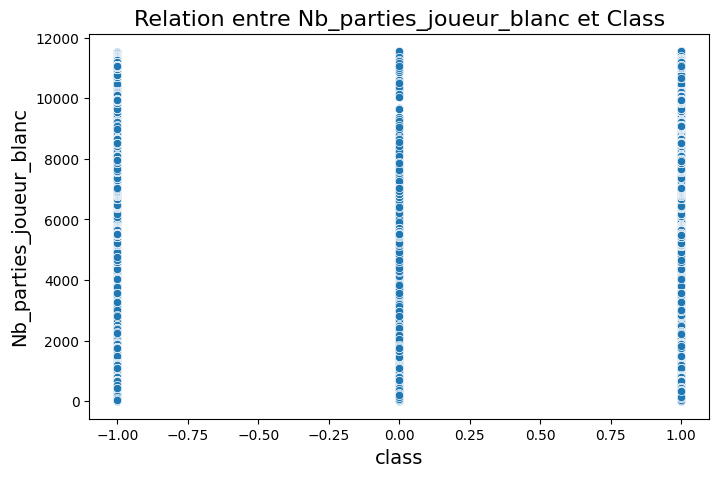

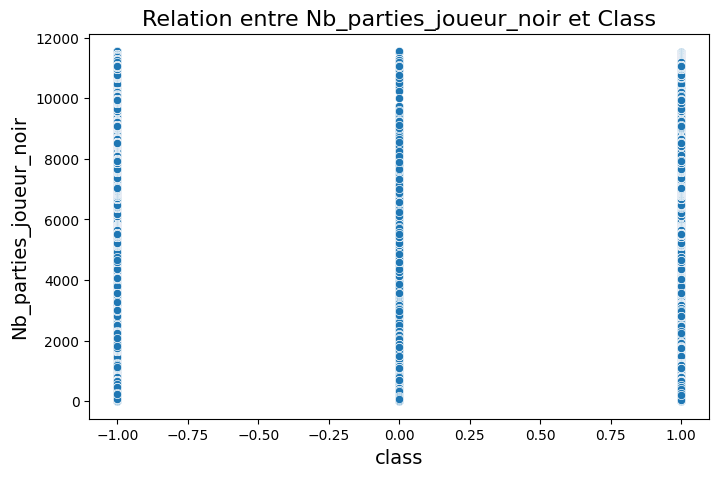

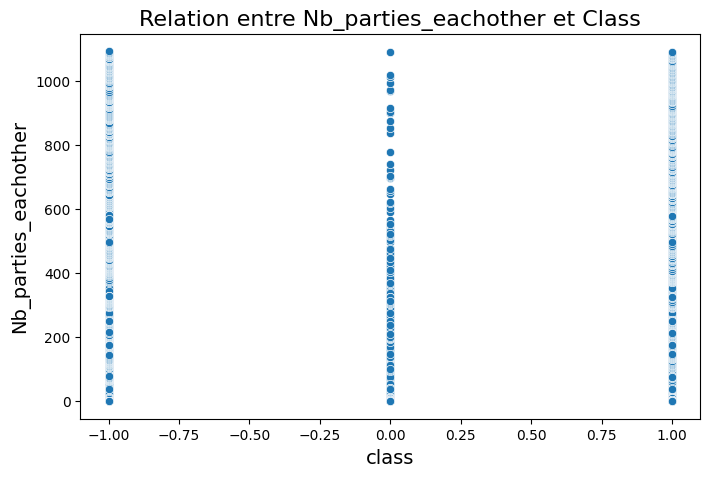

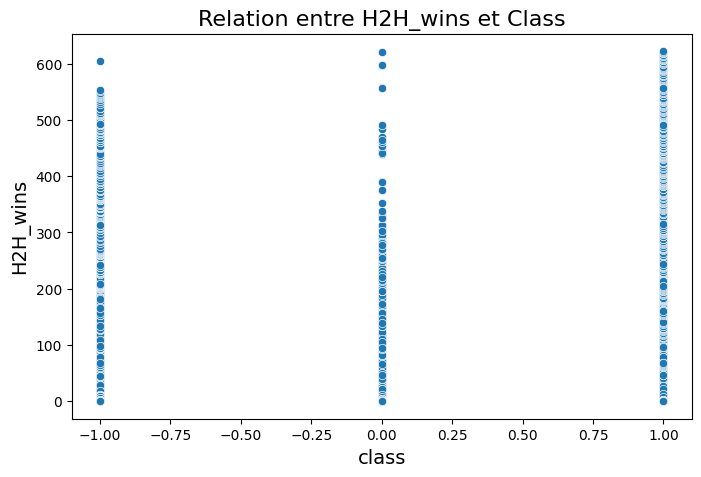

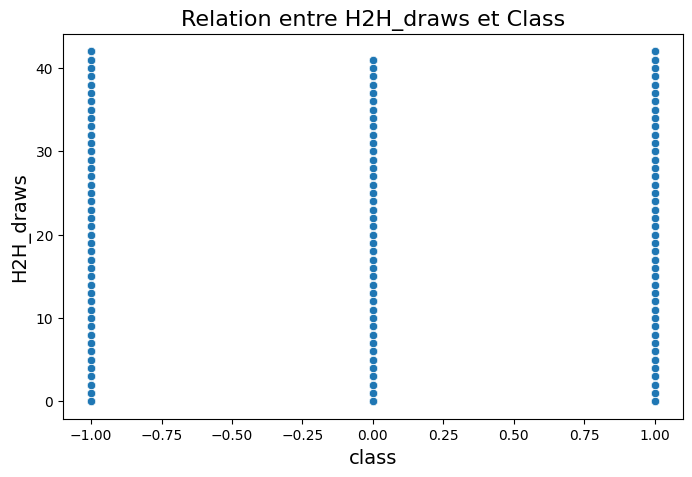

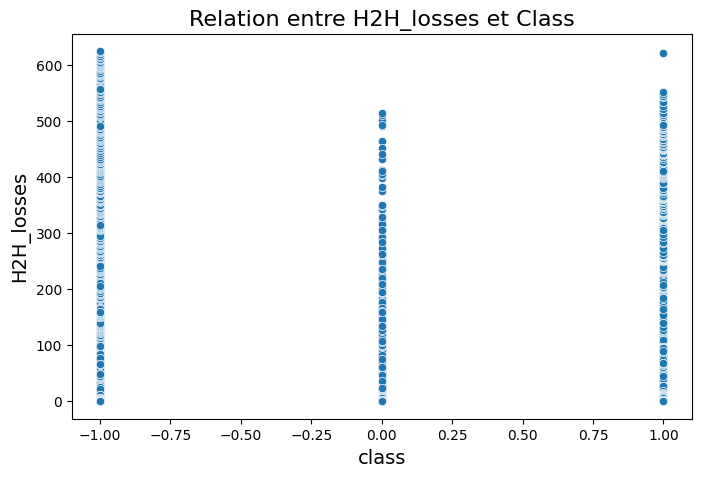

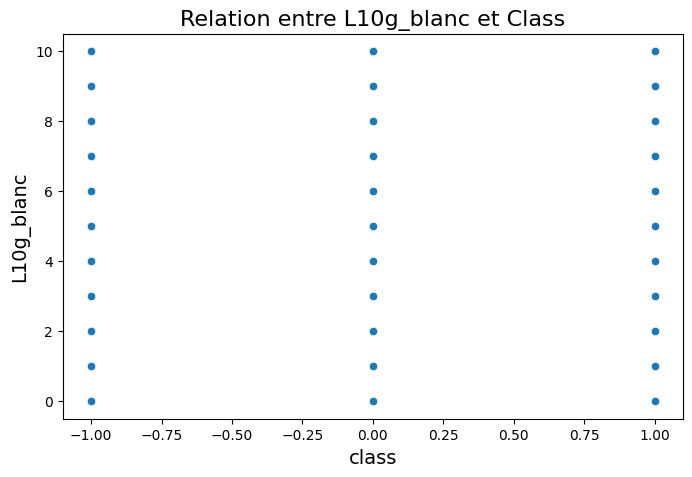

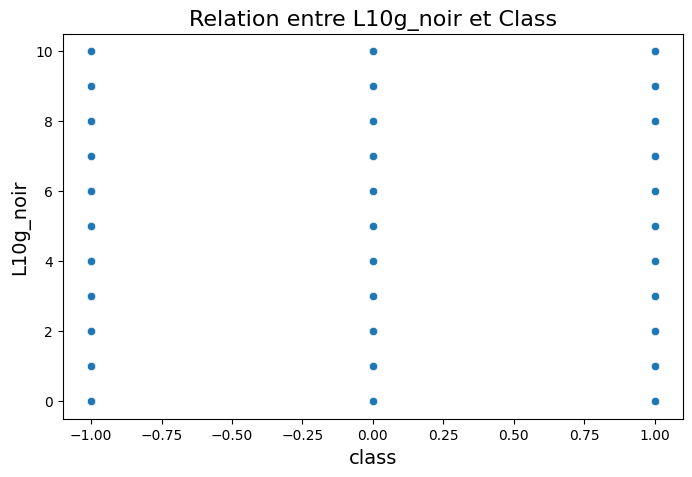

In [ ]:
# Relations Target vs Features
for feature in df_cols:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(y=df_features[feature], x=df_target)
    plt.title(f'Relation entre {feature} et Class', fontsize=16)
    plt.xlabel('class', fontsize=14)
    plt.ylabel(feature, fontsize=14)
    plt.show()

# Feature Selection
## Matrice de correlation

In [ ]:
#on va devoir maper la colonne result pour ca
maping = {'Blanc':1,'Noir':-1,'Draw':0}
dfParties['Winner'] = dfParties['Winner'].map(maping)

In [ ]:
dfParties.head()

,Player white,Player black,Date partie,ELO white,ELO black,Type de partie,Platform,Diff ELO,Winner,Nb_parties_joueur_blanc,Nb_parties_joueur_noir,Nb_parties_eachother,H2H_wins,H2H_draws,H2H_losses,L10g_blanc,L10g_noir
0,vi_pranav,SuperPower2011,1980-01-01,3123,2969,2,chesscom,154,-1,0,0,0,0,0,0,0,0
1,nihalsarin2004,RakitinD,1980-01-01,3323,3116,3,lichess,207,1,532,584,0,0,0,0,0,0
2,Night-King96,tinymonster,1980-01-01,3235,2999,3,lichess,236,1,409,170,0,0,0,0,0,0
3,tinymonster,Night-King96,1980-01-01,3002,3232,3,lichess,-230,-1,171,410,1,0,0,1,0,1
4,Night-King96,tinymonster,1980-01-01,3230,3004,3,lichess,226,1,411,172,2,2,0,0,2,0


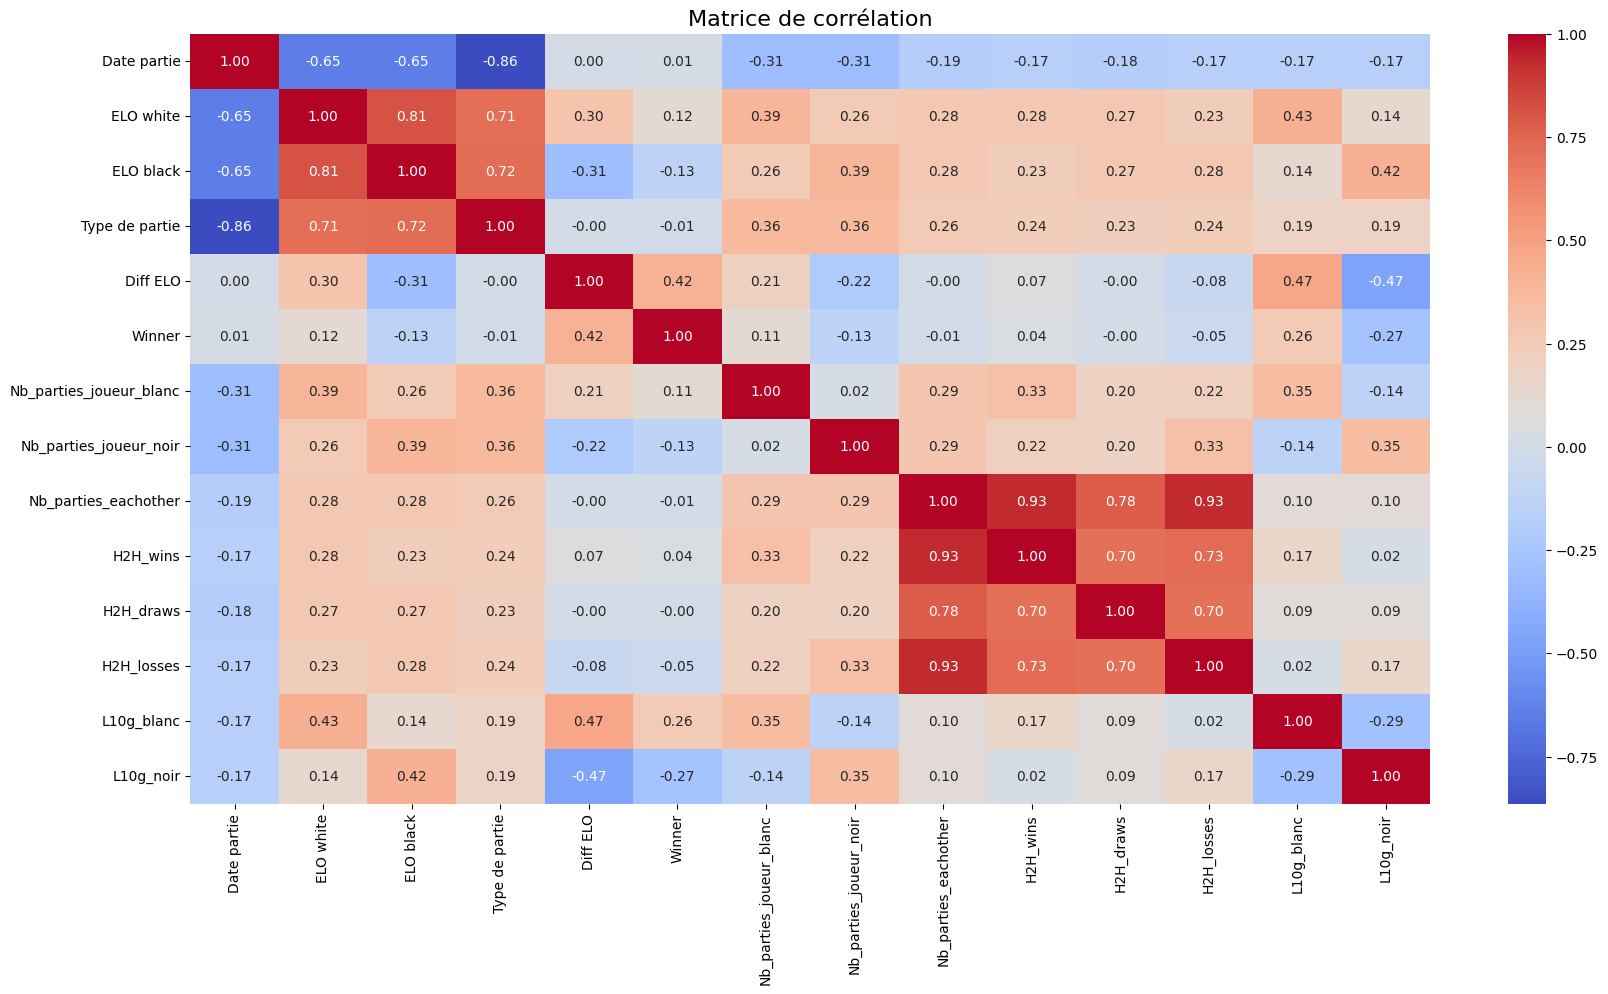

In [ ]:
# Matrice de correlation
corr_df = dfParties.select_dtypes(exclude=['object'])
corr = corr_df.corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Matrice de corrélation', fontsize=16)
plt.show()

In [ ]:
df_featureSelection = df_features[["ELO white","ELO black","Diff ELO","Nb_parties_joueur_blanc","Nb_parties_joueur_noir","L10g_blanc","L10g_noir","Type de partie"]]

In [ ]:
df_featureSelection.head()

,ELO white,ELO black,Diff ELO,Nb_parties_joueur_blanc,Nb_parties_joueur_noir,L10g_blanc,L10g_noir,Type de partie
0,3123,2969,154,0,0,0,0,blitz
1,3323,3116,207,532,584,0,0,bullet
2,3235,2999,236,409,170,0,0,bullet
3,3002,3232,-230,171,410,0,1,bullet
4,3230,3004,226,411,172,2,0,bullet


# Features scaling

In [ ]:
map ={'classical':0,'rapid':1,'blitz':2,'bullet':3}

df_featureSelection['Type de partie']=df_featureSelection['Type de partie'].map(map)

C:\Users\rasse\AppData\Local\Temp\ipykernel_8588\2907696614.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_featureSelection['Type de partie']=df_featureSelection['Type de partie'].map(map)


In [ ]:
df_featureSelection.head()

,ELO white,ELO black,Diff ELO,Nb_parties_joueur_blanc,Nb_parties_joueur_noir,L10g_blanc,L10g_noir,Type de partie
0,3123,2969,154,0,0,0,0,2
1,3323,3116,207,532,584,0,0,3
2,3235,2999,236,409,170,0,0,3
3,3002,3232,-230,171,410,0,1,3
4,3230,3004,226,411,172,2,0,3


In [ ]:
st_scaler = StandardScaler() #
X_preproc = st_scaler.fit(df_featureSelection)
X_preproc = st_scaler.transform(df_featureSelection)
y = df_target

Variances des features numériques:
Nb_parties_joueur_blanc    1.894906e+06
Nb_parties_joueur_noir     1.888163e+06
ELO black                  1.918776e+05
ELO white                  1.914596e+05
Diff ELO                   7.149486e+04
L10g_noir                  6.905586e+00
L10g_blanc                 6.890574e+00
Type de partie             1.523789e+00
dtype: float64



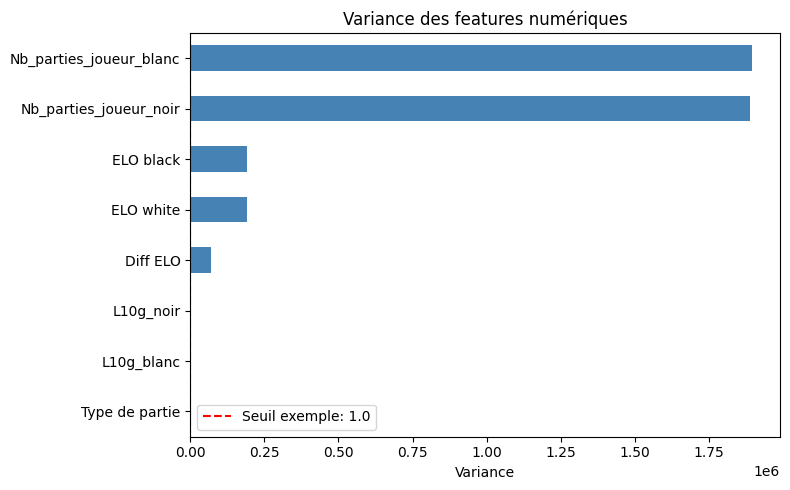

In [ ]:
#Variances
# Calcul des variances

variances = df_featureSelection.var()

print('Variances des features numériques:')
print(variances.sort_values(ascending=False))
print()

# Visualisation
plt.figure(figsize=(8, 5))
variances.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Variance')
plt.title('Variance des features numériques')
plt.axvline(0.005, color='red', linestyle='--', label='Seuil exemple: 1.0') #add a vertical line spanning the whole or fraction of the axes
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df_cols = df_featureSelection.columns.tolist()
df_cols

['ELO white',
 'ELO black',
 'Diff ELO',
 'Nb_parties_joueur_blanc',
 'Nb_parties_joueur_noir',
 'L10g_blanc',
 'L10g_noir',
 'Type de partie']

In [ ]:
map ={'classical':0,'rapid':1,'blitz':2,'bullet':3}

dfParties['Type de partie']=dfParties['Type de partie'].map(map)

In [ ]:
# Application du VarianceThreshold avec sklearn
threshold_value = 0.05  # Seuil arbitraire en fonction des moyennes des variables discriminantes (0.05 bonne valeur de depart quand on ne connait rien) -> on fit le model avec des valeurs de threshold differentes et on voit ce qui ameliore ou pas 
numeric_df = dfParties.select_dtypes(include=['number'])
numeric_features = df_cols

selector = VarianceThreshold(threshold=threshold_value)#feature selector that removes all low variance features 
X_numeric = dfParties[numeric_features]
selector.fit(X_numeric)#using the VarianceThreshold

# Récupérer les variances
variances = selector.variances_  # Array des variances pour chaque feature
print(f'variances {variances}')

# Features conservées
selected_mask = selector.get_support() #get a mask of the features selected 
selected_features = X_numeric.columns[selected_mask].tolist()
rejected_features = X_numeric.columns[~selected_mask].tolist()

print(f'✅ Features conservées (variance > {threshold_value}): {selected_features}')
print(f'❌ Features rejetées (variance ≤ {threshold_value}): {rejected_features}')

variances [1.91459145e+05 1.91877179e+05 7.14946952e+04 1.89490153e+06
 1.88815892e+06 6.89055798e+00 6.90556968e+00 1.52378508e+00]
✅ Features conservées (variance > 0.05): ['ELO white', 'ELO black', 'Diff ELO', 'Nb_parties_joueur_blanc', 'Nb_parties_joueur_noir', 'L10g_blanc', 'L10g_noir', 'Type de partie']
❌ Features rejetées (variance ≤ 0.05): []


Multicolinérité

In [ ]:
corr

,Date partie,ELO white,ELO black,Type de partie,Diff ELO,Nb_parties_joueur_blanc,Nb_parties_joueur_noir,Nb_parties_eachother,H2H_wins,H2H_draws,H2H_losses,L10g_blanc,L10g_noir
Date partie,1.000000,-0.647218,-0.649089,-0.864312,0.004221,-0.310606,-0.310846,-0.186400,-0.171371,-0.183293,-0.171608,-0.167968,-0.167928
ELO white,-0.647218,1.000000,0.813494,0.714473,0.303754,0.393254,0.261603,0.277559,0.278420,0.273675,0.232194,0.425656,0.136897
ELO black,-0.649089,0.813494,1.000000,0.716565,-0.306992,0.264009,0.392574,0.277829,0.232456,0.273900,0.278720,0.138648,0.423677
Type de partie,-0.864312,0.714473,0.716565,1.000000,-0.004702,0.364464,0.364318,0.261870,0.242194,0.226733,0.242448,0.186602,0.185932
Diff ELO,0.004221,0.303754,-0.306992,-0.004702,1.000000,0.211031,-0.215027,-0.000939,0.074802,-0.000858,-0.076634,0.469424,-0.470056
Nb_parties_joueur_blanc,-0.310606,0.393254,0.264009,0.364464,0.211031,1.000000,0.020440,0.292702,0.327862,0.201952,0.218448,0.349507,-0.138851
Nb_parties_joueur_noir,-0.310846,0.261603,0.392574,0.364318,-0.215027,0.020440,1.000000,0.292440,0.217793,0.200084,0.328324,-0.139692,0.348741
Nb_parties_eachother,-0.186400,0.277559,0.277829,0.261870,-0.000939,0.292702,0.292440,1.000000,0.929547,0.775448,0.929362,0.101686,0.101001
H2H_wins,-0.171371,0.278420,0.232456,0.242194,0.074802,0.327862,0.217793,0.929547,1.000000,0.702658,0.729419,0.169160,0.017959
H2H_draws,-0.183293,0.273675,0.273900,0.226733,-0.000858,0.201952,0.200084,0.775448,0.702658,1.000000,0.702594,0.091702,0.090248


In [ ]:
df_cols

['ELO white',
 'ELO black',
 'Diff ELO',
 'Nb_parties_joueur_blanc',
 'Nb_parties_joueur_noir',
 'L10g_blanc',
 'L10g_noir',
 'Type de partie']

In [ ]:
# Détection de multicolinéarité (features très corrélées entre elles)
threshold_multicol = 0.8
multicol_pairs = []

for i in range(len(df_cols)):
    for j in range(i+1, len(df_cols)): # on va tester les features 2 par 2 
        feat1, feat2 = df_cols[i], df_cols[j]
        r = corr.loc[feat1, feat2]#retourne la case du DF representant la relation entre feat1 et feat 2
        if abs(r) > threshold_multicol: # si les variables sont corelées 
            # Quelle feature garder ?
            corr1 = abs(corr.loc[feat1, 'Winner'])
            corr2 = abs(corr.loc[feat2, 'Winner'])
            to_keep = feat1 if corr1 >= corr2 else feat2 # on prend la plus correlé avec la target 
            to_drop = feat2 if to_keep == feat1 else feat1
            multicol_pairs.append({
                'feat1': feat1, 'feat2': feat2, 'corr': r,
                'keep': to_keep, 'drop': to_drop, 'reason': 'plus corrélée à target'
            })

if multicol_pairs:
    print(f'⚠️ Multicolinéarité détectée (|r| > {threshold_multicol}):')
    for pair in multicol_pairs:
        print(f"  • {pair['feat1']} ↔ {pair['feat2']} : r={pair['corr']:.3f}")
        print(f"    → Garder {pair['keep']}, ignorer {pair['drop']} ({pair['reason']})")
else:
    print(f'✅ Aucune multicolinéarité forte détectée (seuil |r| > {threshold_multicol})')

⚠️ Multicolinéarité détectée (|r| > 0.8):
  • ELO white ↔ ELO black : r=0.813
    → Garder ELO black, ignorer ELO white (plus corrélée à target)


## Train Test Split()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_preproc, y, test_size=0.2)

# Modeling
## RandomForrest

In [ ]:
df_sample = df_featureSelection.sample(n=50_000, random_state=42)  # 50k lignes
# refaire un train test split ici !!!!!
# X_preproc = st_scaler.transform(df_featureSelection)
# y = df_target

In [ ]:
rdclf = RandomForestClassifier(random_state=0)
params = {'max_depth':[16,24],'criterion':['gini'],'min_samples_split':[50,100,200],'min_samples_leaf':[20,35,50],'n_estimators':[200,350,500]}
#min_samples_split : combien d'echantillon minimum pour qu'il devienne une feuille (si param : 5 et nombre echntillon = 3 -> ca devient une feuille)
#min samples leaf : combien d'echantillon pour une feuille si 20 et split donne (3/97) le noeud devient une feuille

search = RandomizedSearchCV(
    rdclf, params,
    n_iter=30,        # 30 combinaisons aléatoires au lieu de 162
    cv=5,
    n_jobs=-1,#utilisation mutli coeurs
    random_state=42,
    verbose = 2 #voir ou il en est
)
search.fit(X_train, y_train)

# Récupère les résultats
results = pd.DataFrame(search.cv_results_)

# Colonnes utiles triées par rank
cols = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_max_depth',
    'param_criterion',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'param_n_estimators',
    'mean_fit_time'
]

results_sorted = (results[cols]
                  .sort_values('rank_test_score')
                  .reset_index(drop=True))

# Arrondir pour la lisibilité
results_sorted['mean_test_score'] = results_sorted['mean_test_score'].round(4)
results_sorted['std_test_score']  = results_sorted['std_test_score'].round(4)
results_sorted['mean_fit_time']   = results_sorted['mean_fit_time'].round(1)

results_sorted

Fitting 5 folds for each of 30 candidates, totalling 150 fits


KeyboardInterrupt: 

In [ ]:
results_sorted.tail()

,rank_test_score,mean_test_score,std_test_score,param_max_depth,param_criterion,param_min_samples_split,param_min_samples_leaf,param_n_estimators,mean_fit_time
25,26,0.6424,0.0008,16,gini,50,35,500,391.6
26,27,0.6424,0.0005,24,entropy,50,20,200,203.9
27,28,0.6423,0.0010,24,entropy,200,50,350,294.6
28,29,0.6423,0.0008,16,gini,50,35,350,285.3
29,30,0.6423,0.0006,24,entropy,50,20,500,514.7


In [ ]:
#aucune variation selon les HP 
#faire cross val
#faire learning curve

In [ ]:
best_rf = search.best_estimator_

NameError: name 'search' is not defined

In [ ]:
N, train_score, val_score = learning_curve(best_rf, X_train, y_train,
                                           train_sizes=np.linspace(0.3, 1, 5), cv=3,n_jobs = -1,verbose=3,scoring='roc_auc')

print(N)
plt.plot(N, train_score.mean(axis=1), label='train')
plt.plot(N, val_score.mean(axis=1), label='validation')
plt.xlabel('train_sizes')
plt.legend()

NameError: name 'best_rf' is not defined

## Cross Validation

[CV] END .......max_depth=2;, score=(train=0.634, test=0.634) total time=  19.7s
[CV] END .......max_depth=4;, score=(train=0.638, test=0.638) total time=  31.6s
[CV] END .......max_depth=8;, score=(train=0.641, test=0.639) total time=  52.0s
[CV] END ......max_depth=16;, score=(train=0.656, test=0.641) total time= 1.3min
[CV] END ......max_depth=32;, score=(train=0.658, test=0.642) total time= 1.6min
[CV] END ......max_depth=64;, score=(train=0.658, test=0.642) total time= 1.3min
[CV] END .......max_depth=2;, score=(train=0.634, test=0.635) total time=  20.5s
[CV] END .......max_depth=4;, score=(train=0.638, test=0.639) total time=  34.4s
[CV] END .......max_depth=8;, score=(train=0.641, test=0.641) total time=  57.5s
[CV] END ......max_depth=16;, score=(train=0.656, test=0.644) total time= 1.3min
[CV] END ......max_depth=32;, score=(train=0.658, test=0.644) total time= 1.3min
[CV] END ......max_depth=64;, score=(train=0.658, test=0.644) total time= 1.3min
[CV] END .......max_depth=2;

[Parallel(n_jobs=1)]: Done  30 out of  30 | elapsed: 31.8min finished


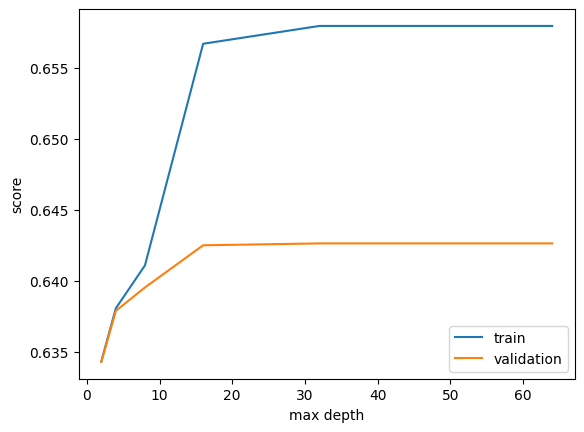

In [ ]:
k = [2,4,8,16,32,64]

train_score, val_score = validation_curve(best_rf, X_train, y_train,param_name=
                                          'max_depth', param_range=k, cv=5, scoring='accuracy',verbose = 3,n_jobs=-1)

plt.plot(k, train_score.mean(axis=1), label='train')
plt.plot(k, val_score.mean(axis=1), label='validation')

plt.ylabel('score')
plt.xlabel('max depth')
plt.legend()

max depth : 5 sinon overfitting a 10

[CV] END ...n_estimators=50;, score=(train=0.658, test=0.642) total time=  22.8s
[CV] END ..n_estimators=100;, score=(train=0.658, test=0.642) total time=  49.3s
[CV] END ..n_estimators=200;, score=(train=0.658, test=0.642) total time= 1.4min
[CV] END ..n_estimators=500;, score=(train=0.658, test=0.642) total time= 3.4min
[CV] END ...n_estimators=50;, score=(train=0.657, test=0.644) total time=  20.1s
[CV] END ..n_estimators=100;, score=(train=0.657, test=0.644) total time=  39.7s
[CV] END ..n_estimators=200;, score=(train=0.658, test=0.644) total time= 1.4min
[CV] END ..n_estimators=500;, score=(train=0.658, test=0.644) total time= 3.4min
[CV] END ...n_estimators=50;, score=(train=0.658, test=0.643) total time=  21.0s
[CV] END ..n_estimators=100;, score=(train=0.658, test=0.643) total time=  42.7s
[CV] END ..n_estimators=200;, score=(train=0.658, test=0.643) total time= 1.5min
[CV] END ..n_estimators=500;, score=(train=0.658, test=0.643) total time= 4.4min
[CV] END ...n_estimators=50;

[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed: 33.6min finished


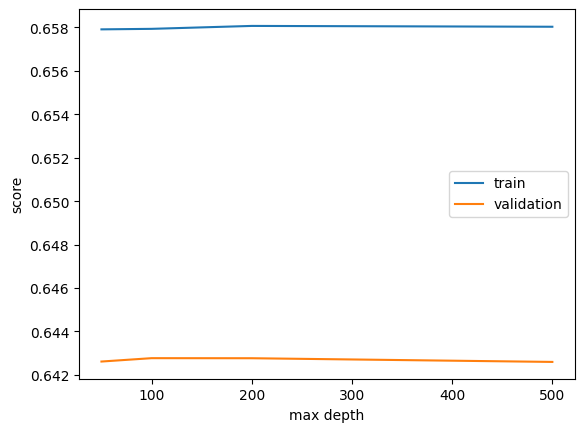

In [ ]:
k = [50,100,200,500]

train_score, val_score = validation_curve(best_rf, X_train, y_train,param_name=
                                          'n_estimators', param_range=k, cv=5, scoring='accuracy',verbose = 3,n_jobs=-1)

plt.plot(k, train_score.mean(axis=1), label='train')
plt.plot(k, val_score.mean(axis=1), label='validation')

plt.ylabel('score')
plt.xlabel('n_estim')
plt.legend()

max depth : 5 sinon overfitting a 10
n_estimator reste stable -> on fixe à 50

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of  25 | elapsed:  6.2min remaining: 13.3min
[Parallel(n_jobs=-1)]: Done  17 out of  25 | elapsed: 14.7min remaining:  6.9min
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed: 19.0min finished


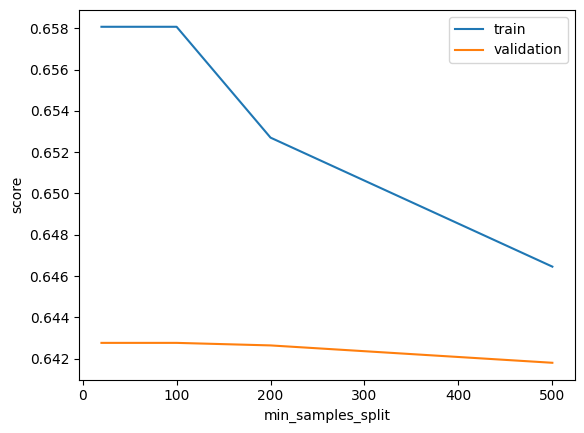

In [ ]:
k = [20,50,100,200,500]

train_score, val_score = validation_curve(best_rf, X_train, y_train,param_name=
                                          'min_samples_split', param_range=k, cv=5, scoring='accuracy',verbose = 3,n_jobs=-1)

plt.plot(k, train_score.mean(axis=1), label='train')
plt.plot(k, val_score.mean(axis=1), label='validation')

plt.ylabel('score')
plt.xlabel('min_samples_split')
plt.legend()

max depth : 5 sinon overfitting a 10
n_estimator reste stable -> on fixe à 50
min_samples_split se degrade a partir de 100

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of  20 | elapsed:  6.0min remaining: 11.2min
[Parallel(n_jobs=-1)]: Done  14 out of  20 | elapsed: 12.1min remaining:  5.2min
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed: 15.3min finished


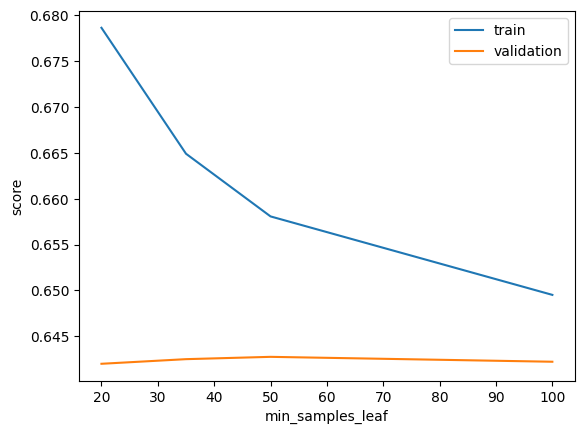

In [ ]:
k = [20,35,50,100]

train_score, val_score = validation_curve(best_rf, X_train, y_train,param_name=
                                          'min_samples_leaf', param_range=k, cv=5, scoring='accuracy',verbose = 3,n_jobs=-1)

plt.plot(k, train_score.mean(axis=1), label='train')
plt.plot(k, val_score.mean(axis=1), label='validation')

plt.ylabel('score')
plt.xlabel('min_samples_leaf')
plt.legend()

max depth : 5 sinon overfitting a 10    
n_estimator reste stable -> on fixe à 50    
min_samples_split se degrade a partir de 100    
min_samples_leaf degrade dès 20     

In [ ]:
rdclf = RandomForestClassifier(random_state=0)
params = {'max_depth':[5,6,7],'criterion':['gini'],'min_samples_split':[20,50,100],'min_samples_leaf':[5,10,20],'n_estimators':[50]}
#min_samples_split : combien d'echantillon minimum pour qu'il devienne une feuille (si param : 5 et nombre echntillon = 3 -> ca devient une feuille)
#min samples leaf : combien d'echantillon pour une feuille si 20 et split donne (3/97) le noeud devient une feuille

grid = GridSearchCV(rdclf,param_grid=params,verbose = 3,cv=5,n_jobs=-1)
grid.fit(X_train, y_train)

# Récupère les résultats
results = pd.DataFrame(grid.cv_results_)

# Colonnes utiles triées par rank
cols = [
    'rank_test_score',      
    'mean_test_score',
    'std_test_score',
    'param_max_depth',
    'param_criterion',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'param_n_estimators',
    'mean_fit_time'
]

results_sorted = (results[cols]
                  .sort_values('rank_test_score')
                  .reset_index(drop=True))

# Arrondir pour la lisibilité
results_sorted['mean_test_score'] = results_sorted['mean_test_score'].round(4)
results_sorted['std_test_score']  = results_sorted['std_test_score'].round(4)
results_sorted['mean_fit_time']   = results_sorted['mean_fit_time'].round(1)

results_sorted

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,rank_test_score,mean_test_score,std_test_score,param_max_depth,param_criterion,param_min_samples_split,param_min_samples_leaf,param_n_estimators,mean_fit_time
0,1,0.6390,0.0010,7,gini,100,5,50,28.1
1,2,0.6390,0.0011,7,gini,50,5,50,28.5
2,3,0.6390,0.0012,7,gini,20,5,50,28.6
3,4,0.6389,0.0011,7,gini,20,10,50,28.4
4,5,0.6389,0.0011,7,gini,50,10,50,28.9
5,6,0.6389,0.0011,7,gini,100,10,50,29.0
6,7,0.6389,0.0010,7,gini,100,20,50,27.6
7,8,0.6388,0.0011,7,gini,50,20,50,29.1
8,9,0.6388,0.0011,7,gini,20,20,50,29.0
9,10,0.6383,0.0009,6,gini,20,5,50,26.5


In [ ]:
rdclf_new_best = grid.best_estimator_

In [ ]:
rdclf_new_best.fit(X_train,y_train)
# TODO C: Prédire les résultats sur l'ensemble de test.
y_pred = rdclf_new_best.predict(X_test)
# TODO D: Afficher la précision (accuracy) et le rapport de classification.
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nMatrice de confusion:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.64

Classification Report:
              precision    recall  f1-score   support

          -1       0.62      0.71      0.66     35610
           0       0.53      0.01      0.01      9964
           1       0.66      0.73      0.69     39765

    accuracy                           0.64     85339
   macro avg       0.60      0.48      0.46     85339
weighted avg       0.63      0.64      0.60     85339


Matrice de confusion:
[[25376    26 10208]
 [ 5018    62  4884]
 [10739    28 28998]]


In [ ]:
df_featureSelection

,ELO white,ELO black,Diff ELO,Nb_parties_joueur_blanc,Nb_parties_joueur_noir,L10g_blanc,L10g_noir
0,3123,2969,154,0,0,0,0
1,3323,3116,207,532,584,0,0
2,3235,2999,236,409,170,0,0
3,3002,3232,-230,171,410,0,1
4,3230,3004,226,411,172,2,0
...,...,...,...,...,...,...,...
426689,2645,2507,138,341,205,7,7
426690,2532,2698,-166,51,232,4,7
426691,2486,2390,96,81,129,2,4
426692,2597,2423,174,131,94,6,6


Desiquilibre de classe pour le draw, essayons de balancer les classes

In [ ]:
#params = {'max_depth':[5,6,7],'criterion':['gini'],'min_samples_split':[20,50,100],'min_samples_leaf':[5,10,20],'n_estimators':[50]}

In [ ]:
# Option A : class_weight dans RandomForestClassifier
rdclf_try_classbalanced = RandomForestClassifier(class_weight='balanced', random_state=0,max_depth=6,criterion='gini',min_samples_split=20,min_samples_leaf=10,n_estimators=50)
rdclf_try_classbalanced.fit(X_train,y_train)
# TODO C: Prédire les résultats sur l'ensemble de test.
y_pred = rdclf_try_classbalanced.predict(X_test)
# TODO D: Afficher la précision (accuracy) et le rapport de classification.
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nMatrice de confusion:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.59

Classification Report:
              precision    recall  f1-score   support

          -1       0.64      0.62      0.63     35610
           0       0.26      0.45      0.33      9964
           1       0.70      0.60      0.64     39765

    accuracy                           0.59     85339
   macro avg       0.53      0.55      0.53     85339
weighted avg       0.63      0.59      0.60     85339


Matrice de confusion:
[[22022  6113  7475]
 [ 2835  4484  2645]
 [ 9308  6742 23715]]


plus équilibré mais on passe de 64 à 59% d'accuracy

essayons de rajouter quelques features

In [176]:
dftry2 = df_featureSelection.copy()

In [177]:
dftry2.head()

,ELO white,ELO black,Diff ELO,Nb_parties_joueur_blanc,Nb_parties_joueur_noir,L10g_blanc,L10g_noir,Type de partie
0,3123,2969,154,0,0,0,0,2
1,3323,3116,207,532,584,0,0,3
2,3235,2999,236,409,170,0,0,3
3,3002,3232,-230,171,410,0,1,3
4,3230,3004,226,411,172,2,0,3


In [178]:
# Avantage couleur (feature binaire simple mais puissante)
dftry2['is_white_advantage'] = 1  # toujours 1 si tu préds du point de vue blanc

# Ratio de victoire récente (plus stable que le compte brut)
dftry2['white_winrate_10'] = dftry2['L10g_blanc'] / 10
dftry2['black_winrate_10'] = dftry2['L10g_noir'] / 10

# Interaction ELO × couleur
dftry2['elo_diff_color_adjusted'] = dftry2['ELO white'] - dftry2['ELO black'] + 35  # +35 = avantage blanc empirique

# Forme relative récente
dftry2['form_diff'] = dftry2['L10g_blanc'] - dftry2['L10g_noir']

dftry2['white_is_stronger'] = (dftry2['ELO white'] > dftry2['ELO black']).astype(int)

dftry2.drop(columns=['L10g_blanc','L10g_noir','Diff ELO'],inplace=True)

In [179]:
dftry2.head()

,ELO white,ELO black,Nb_parties_joueur_blanc,Nb_parties_joueur_noir,Type de partie,is_white_advantage,white_winrate_10,black_winrate_10,elo_diff_color_adjusted,form_diff,white_is_stronger
0,3123,2969,0,0,2,1,0.0,0.0,189,0,1
1,3323,3116,532,584,3,1,0.0,0.0,242,0,1
2,3235,2999,409,170,3,1,0.0,0.0,271,0,1
3,3002,3232,171,410,3,1,0.0,0.1,-195,-1,0
4,3230,3004,411,172,3,1,0.2,0.0,261,2,1


In [ ]:
st_scaler = StandardScaler() #
X_preproc = st_scaler.fit(dftry2)
X_preproc = st_scaler.transform(dftry2)
y = df_target

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X_preproc, y, test_size=0.2)

In [ ]:
# Option A : class_weight dans RandomForestClassifier
rdclf_try_classbalanced = RandomForestClassifier(class_weight='balanced', random_state=0,max_depth=12,criterion='gini',min_samples_split=10,min_samples_leaf=5,n_estimators=200,n_jobs=-1)
rdclf_try_classbalanced.fit(X_train,y_train)
# TODO C: Prédire les résultats sur l'ensemble de test.
y_pred = rdclf_try_classbalanced.predict(X_test)
# TODO D: Afficher la précision (accuracy) et le rapport de classification.
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nMatrice de confusion:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.60

Classification Report:
              precision    recall  f1-score   support

          -1       0.65      0.64      0.64     35505
           0       0.28      0.43      0.34      9913
           1       0.70      0.62      0.66     39921

    accuracy                           0.60     85339
   macro avg       0.54      0.56      0.55     85339
weighted avg       0.63      0.60      0.61     85339


Matrice de confusion:
[[22588  4966  7951]
 [ 2935  4275  2703]
 [ 9448  5762 24711]]


In [ ]:
rdclf = RandomForestClassifier(random_state=0)
params = {'max_depth':[6,12,18,24],'criterion':['gini'],'min_samples_split':[5,10,20,50],'min_samples_leaf':[5,10,20],'n_estimators':[50,100,200],'class_weight':['balanced']}
#min_samples_split : combien d'echantillon minimum pour qu'il devienne une feuille (si param : 5 et nombre echntillon = 3 -> ca devient une feuille)
#min samples leaf : combien d'echantillon pour une feuille si 20 et split donne (3/97) le noeud devient une feuille

grid = GridSearchCV(rdclf,param_grid=params,verbose = 3,cv=5,n_jobs=-1)
grid.fit(X_train, y_train)

# Récupère les résultats
results = pd.DataFrame(grid.cv_results_)

# Colonnes utiles triées par rank
cols = [
    'rank_test_score',      
    'mean_test_score',
    'std_test_score',
    'param_max_depth',
    'param_criterion',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'param_n_estimators',
    'mean_fit_time'
]

results_sorted = (results[cols]
                  .sort_values('rank_test_score')
                  .reset_index(drop=True))

# Arrondir pour la lisibilité
results_sorted['mean_test_score'] = results_sorted['mean_test_score'].round(4)
results_sorted['std_test_score']  = results_sorted['std_test_score'].round(4)
results_sorted['mean_fit_time']   = results_sorted['mean_fit_time'].round(1)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


In [ ]:
results_sorted

,rank_test_score,mean_test_score,std_test_score,param_max_depth,param_criterion,param_min_samples_split,param_min_samples_leaf,param_n_estimators,mean_fit_time
0,1,0.6255,0.0010,24,gini,5,5,200,235.5
1,1,0.6255,0.0010,24,gini,10,5,200,235.7
2,3,0.6248,0.0014,24,gini,10,5,100,117.3
3,3,0.6248,0.0014,24,gini,5,5,100,117.0
4,5,0.6230,0.0010,24,gini,5,5,50,60.5
...,...,...,...,...,...,...,...,...,...
139,140,0.5931,0.0018,6,gini,10,20,50,27.9
140,140,0.5931,0.0018,6,gini,5,20,50,27.8
141,140,0.5931,0.0018,6,gini,20,20,50,27.7
142,143,0.5930,0.0016,6,gini,50,10,50,28.3


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  15 | elapsed:  3.4min remaining:  9.3min
[Parallel(n_jobs=-1)]: Done  10 out of  15 | elapsed: 10.2min remaining:  5.1min
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed: 13.0min finished


InvalidParameterError: The 'max_depth' parameter of RandomForestClassifier must be an int in the range [1, inf) or None. Got [24, 48, 96] instead.

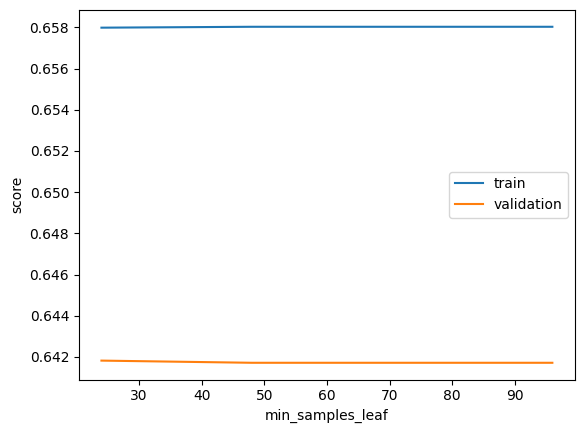

In [ ]:

rdclf_try_classbalanced = RandomForestClassifier(class_weight='balanced', random_state=0,max_depth=12,criterion='gini',min_samples_split=5,min_samples_leaf=5,n_estimators=200,n_jobs=-1)
train_score, val_score = validation_curve(best_rf, X_train, y_train,param_name=
                                          'max_depth', param_range=k, cv=5, scoring='accuracy',verbose = 3,n_jobs=-1)

plt.plot(k, train_score.mean(axis=1), label='train')
plt.plot(k, val_score.mean(axis=1), label='validation')

plt.ylabel('score')
plt.xlabel('max_depth')
plt.legend()





In [ ]:
k = [24,48,96]
# Option A : class_weight dans RandomForestClassifier
for e in k:
    rdclf_try_classbalanced = RandomForestClassifier(class_weight='balanced', random_state=0,max_depth=e,criterion='gini',min_samples_split=5,min_samples_leaf=5,n_estimators=200,n_jobs=-1)

    rdclf_try_classbalanced.fit(X_train,y_train)
    # TODO C: Prédire les résultats sur l'ensemble de test.
    y_pred = rdclf_try_classbalanced.predict(X_test)
    # TODO D: Afficher la précision (accuracy) et le rapport de classification.
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nMatrice de confusion:")
    print(confusion_matrix(y_test, y_pred))

Accuracy: 0.63

Classification Report:
              precision    recall  f1-score   support

          -1       0.64      0.66      0.65     35505
           0       0.32      0.33      0.32      9913
           1       0.69      0.67      0.68     39921

    accuracy                           0.63     85339
   macro avg       0.55      0.55      0.55     85339
weighted avg       0.63      0.63      0.63     85339


Matrice de confusion:
[[23557  3127  8821]
 [ 3347  3229  3337]
 [ 9670  3613 26638]]
Accuracy: 0.63

Classification Report:
              precision    recall  f1-score   support

          -1       0.64      0.66      0.65     35505
           0       0.33      0.31      0.32      9913
           1       0.68      0.67      0.68     39921

    accuracy                           0.63     85339
   macro avg       0.55      0.55      0.55     85339
weighted avg       0.62      0.63      0.63     85339


Matrice de confusion:
[[23565  2920  9020]
 [ 3417  3063  3433]
 [ 9680 

In [ ]:
k = [5,3,2]
# Option A : class_weight dans RandomForestClassifier
for e in k:
    rdclf_try_classbalanced = RandomForestClassifier(class_weight='balanced', random_state=0,max_depth=24,criterion='gini',min_samples_split=e,min_samples_leaf=5,n_estimators=200,n_jobs=-1)

    rdclf_try_classbalanced.fit(X_train,y_train)
    # TODO C: Prédire les résultats sur l'ensemble de test.
    y_pred = rdclf_try_classbalanced.predict(X_test)
    # TODO D: Afficher la précision (accuracy) et le rapport de classification.
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nMatrice de confusion:")
    print(confusion_matrix(y_test, y_pred))

Accuracy: 0.63

Classification Report:
              precision    recall  f1-score   support

          -1       0.64      0.66      0.65     35505
           0       0.32      0.33      0.32      9913
           1       0.69      0.67      0.68     39921

    accuracy                           0.63     85339
   macro avg       0.55      0.55      0.55     85339
weighted avg       0.63      0.63      0.63     85339


Matrice de confusion:
[[23557  3127  8821]
 [ 3347  3229  3337]
 [ 9670  3613 26638]]
Accuracy: 0.63

Classification Report:
              precision    recall  f1-score   support

          -1       0.64      0.66      0.65     35505
           0       0.32      0.33      0.32      9913
           1       0.69      0.67      0.68     39921

    accuracy                           0.63     85339
   macro avg       0.55      0.55      0.55     85339
weighted avg       0.63      0.63      0.63     85339


Matrice de confusion:
[[23557  3127  8821]
 [ 3347  3229  3337]
 [ 9670 

InvalidParameterError: The 'min_samples_split' parameter of RandomForestClassifier must be an int in the range [2, inf) or a float in the range (0.0, 1.0]. Got 1 instead.

[learning_curve] Training set sizes: [ 68271 108095 147920 187745 227570]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  15 | elapsed:  2.6min remaining:  7.3min
[Parallel(n_jobs=-1)]: Done  10 out of  15 | elapsed:  5.9min remaining:  3.0min
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:  8.5min finished


[ 68271 108095 147920 187745 227570]


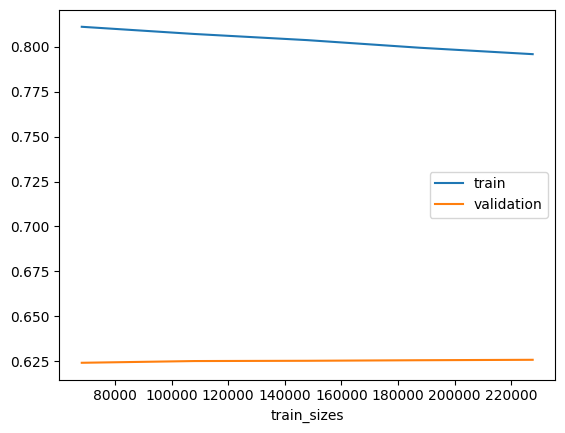

In [ ]:
rdclf_try_classbalanced = RandomForestClassifier(class_weight='balanced', random_state=0,max_depth=24,criterion='gini',min_samples_split=5,min_samples_leaf=5,n_estimators=200,n_jobs=-1)


N, train_score, val_score = learning_curve(rdclf_try_classbalanced, X_train, y_train,
                                           train_sizes=np.linspace(0.3, 1, 5), cv=3,n_jobs = -1,verbose=3)

print(N)
plt.plot(N, train_score.mean(axis=1), label='train')
plt.plot(N, val_score.mean(axis=1), label='validation')
plt.xlabel('train_sizes')
plt.legend()

62% grand max

## let's try deep learning

In [104]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # -1→0, 0→1, 1→2
y_test_enc  = le.transform(y_test)

In [105]:
# Pour numpy array, utilise np.unique()
print(np.unique(y_train_enc))          # équivalent de .unique()
print(np.bincount(y_train_enc))        # équivalent de .value_counts()


[0 1 2]
[159329  39515 142511]


In [106]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils import Tags

class RocAucCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        self.X_val = X_val
        self.y_val = y_val

    def on_epoch_end(self, epoch, logs=None):
        y_proba = self.model.predict(self.X_val, verbose=0)
        auc = roc_auc_score(self.y_val, y_proba, multi_class='ovr', average='macro')
        logs['val_auc_roc'] = auc  # l'ajoute aux logs Keras
        print(f"  → val_AUC-ROC: {auc:.4f}")

class KerasWrapper(BaseEstimator, ClassifierMixin):

    def __init__(self, nb_neuron_1=64, nb_neuron_2=32,
                 dropout_1=0.2, dropout_2=0.3,
                 lr=0.0001, epochs=30, batch_size=256,verbose = 2):
        self.nb_neuron_1 = nb_neuron_1
        self.nb_neuron_2 = nb_neuron_2
        self.dropout_1   = dropout_1
        self.dropout_2   = dropout_2
        self.lr          = lr
        self.epochs      = epochs
        self.batch_size  = batch_size
        self.verbose = verbose

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"  # ← exactement ce que is_classifier() lit
        return tags

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.model_ = Sequential([
            Input(shape=(X.shape[1],)),
            Dense(self.nb_neuron_1, activation='relu', kernel_initializer='he_uniform'),
            Dropout(self.dropout_1),
            Dense(self.nb_neuron_2, activation='relu', kernel_initializer='he_uniform'),
            Dropout(self.dropout_2),
            Dense(3, activation='softmax') #3 resultats
        ])
        self.model_.compile(
            optimizer=tf.keras.optimizers.Adam(self.lr),
            loss='sparse_categorical_crossentropy',
            run_eagerly=True,
            metrics=['accuracy']
        )
        #Céting vlidation data
        X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)
        roc_cb = RocAucCallback(X_val, y_val)
        #Callbacks
        early_stop = EarlyStopping(
        monitor="val_auc_roc",      # ou "val_loss"
        patience=5,          # nombre d'epochs sans amélioration
        restore_best_weights=True,
        mode='max' #sinon early stop suppose qu'on veut minimiser le AUC-ROC
    )
        
        #Fit
        self.model_.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=self.epochs,
        batch_size=self.batch_size,
        callbacks=[roc_cb,early_stop],
        verbose=self.verbose
    )
        return self

    def predict_proba(self, X):
        X = X.astype("float32")
        results = []
        n = len(X)
        for i in range(0, n, self.batch_size):
            batch = X[i : i + self.batch_size]
            pad_size = self.batch_size - len(batch)
            if pad_size > 0:
                pad = np.zeros((pad_size, batch.shape[1]), dtype="float32")
                batch = np.vstack([batch, pad])
            pred = self.model_(batch, training=False).numpy()
            results.append(pred[: self.batch_size - pad_size])
        return np.vstack(results)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)
    def save(self, path):
        self.model_.save(path)


# Vérifie
from sklearn.base import is_classifier
print("Is classifier:", is_classifier(KerasWrapper()))  # doit être True
# ============================================================
# 2. SCORER
# ============================================================
def multiclass_roc_auc(y_true, y_proba):
    return roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')

Is classifier: True


In [107]:
clf = KerasWrapper(epochs=2, batch_size=256)
clf.fit(X_train[:10000], y_train_enc[:10000])
proba = clf.predict_proba(X_train[10000:12000])
print("shape:", proba.shape)
print("score:", multiclass_roc_auc(y_train_enc[10000:12000], proba))

Epoch 1/2
  → val_AUC-ROC: 0.5802
36/36 - 3s - 79ms/step - accuracy: 0.3956 - loss: 1.3429 - val_accuracy: 0.4640 - val_loss: 1.0774 - val_auc_roc: 0.5802
Epoch 2/2
  → val_AUC-ROC: 0.6011
36/36 - 2s - 50ms/step - accuracy: 0.4373 - loss: 1.2530 - val_accuracy: 0.5260 - val_loss: 1.0061 - val_auc_roc: 0.6011
shape: (2000, 3)
score: 0.599233702865106


In [ ]:
roc_auc_scorer = make_scorer(
    multiclass_roc_auc,
    response_method="predict_proba"  
)
param_grid = {
    'nb_neuron_1': [64, 128],
    'nb_neuron_2': [32, 64],
    'dropout_1':   [0.2],
    'lr':          [0.001, 0.0005],
    'batch_size':  [256],        
    'epochs':      [20]      
}

# GridSearch avec validation croisée
grid_search = GridSearchCV(
    estimator=KerasWrapper(),
    param_grid=param_grid,
    cv=3,                    # 3-fold cross-validation 
    scoring=roc_auc_scorer,       # Optimise sur l'AUC
    n_jobs=1,               # Utilise one core -> recommandé pour DL
    verbose=3
)


grid_search.fit(X_train, y_train_enc)

tab_result = pd.DataFrame(grid_search.cv_results_) #met dans tab_result un dataframe avec toutes les variation de parametres 

tab_result.sort_values(by="rank_test_score")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV 1/3] END batch_size=256, dropout_1=0.2, epochs=20, lr=0.001, nb_neuron_1=64, nb_neuron_2=32;, score=0.747 total time=10.1min
[CV 2/3] END batch_size=256, dropout_1=0.2, epochs=20, lr=0.001, nb_neuron_1=64, nb_neuron_2=32;, score=0.747 total time=10.1min
[CV 3/3] END batch_size=256, dropout_1=0.2, epochs=20, lr=0.001, nb_neuron_1=64, nb_neuron_2=32;, score=0.746 total time=10.0min
[CV 1/3] END batch_size=256, dropout_1=0.2, epochs=20, lr=0.001, nb_neuron_1=64, nb_neuron_2=64;, score=0.747 total time=10.1min
[CV 2/3] END batch_size=256, dropout_1=0.2, epochs=20, lr=0.001, nb_neuron_1=64, nb_neuron_2=64;, score=0.747 total time=10.7min
[CV 3/3] END batch_size=256, dropout_1=0.2, epochs=20, lr=0.001, nb_neuron_1=64, nb_neuron_2=64;, score=0.746 total time=10.3min
[CV 1/3] END batch_size=256, dropout_1=0.2, epochs=20, lr=0.001, nb_neuron_1=128, nb_neuron_2=32;, score=0.748 total time=10.1min
[CV 2/3] END batch_size=256, dropout

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_batch_size,param_dropout_1,param_epochs,param_lr,param_nb_neuron_1,param_nb_neuron_2,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
3,634.972145,12.483798,1.727843,0.041592,256,0.2,20,0.0010,128,64,"{'batch_size': 256, 'dropout_1': 0.2, 'epochs'...",0.748129,0.747485,0.746175,0.747263,0.000813,1
1,619.547040,14.261499,1.900353,0.161019,256,0.2,20,0.0010,64,64,"{'batch_size': 256, 'dropout_1': 0.2, 'epochs'...",0.747480,0.747100,0.745947,0.746842,0.000652,2
2,623.438587,13.296690,1.743780,0.061690,256,0.2,20,0.0010,128,32,"{'batch_size': 256, 'dropout_1': 0.2, 'epochs'...",0.747741,0.746728,0.745815,0.746761,0.000787,3
7,630.566333,12.326057,1.821026,0.084938,256,0.2,20,0.0005,128,64,"{'batch_size': 256, 'dropout_1': 0.2, 'epochs'...",0.747692,0.746312,0.745633,0.746546,0.000856,4
0,603.847960,3.469099,1.812579,0.170253,256,0.2,20,0.0010,64,32,"{'batch_size': 256, 'dropout_1': 0.2, 'epochs'...",0.747358,0.746511,0.745629,0.746499,0.000706,5
5,721.486564,137.919198,2.202402,0.191484,256,0.2,20,0.0005,64,64,"{'batch_size': 256, 'dropout_1': 0.2, 'epochs'...",0.746812,0.745870,0.744979,0.745887,0.000748,6
6,605.488668,5.739742,1.741506,0.046347,256,0.2,20,0.0005,128,32,"{'batch_size': 256, 'dropout_1': 0.2, 'epochs'...",0.746813,0.745519,0.745145,0.745826,0.000714,7
4,612.954387,10.214688,1.688316,0.086676,256,0.2,20,0.0005,64,32,"{'batch_size': 256, 'dropout_1': 0.2, 'epochs'...",0.746602,0.744708,0.743937,0.745082,0.001119,8


## CV


[CV] END ....nb_neuron_1=32;, score=(train=0.747, test=0.748) total time=14.2min
[CV] END ....nb_neuron_1=64;, score=(train=0.748, test=0.748) total time=15.1min
[CV] END ...nb_neuron_1=128;, score=(train=0.748, test=0.748) total time=15.5min
[CV] END ...nb_neuron_1=256;, score=(train=0.749, test=0.748) total time=15.6min
[CV] END ...nb_neuron_1=512;, score=(train=0.749, test=0.749) total time=16.5min
[CV] END ....nb_neuron_1=32;, score=(train=0.748, test=0.747) total time=15.5min
[CV] END ....nb_neuron_1=64;, score=(train=0.749, test=0.747) total time=14.9min
[CV] END ...nb_neuron_1=128;, score=(train=0.749, test=0.747) total time=15.2min
[CV] END ...nb_neuron_1=256;, score=(train=0.749, test=0.747) total time=14.9min
[CV] END ...nb_neuron_1=512;, score=(train=0.749, test=0.747) total time=16.1min
[CV] END ....nb_neuron_1=32;, score=(train=0.748, test=0.745) total time=14.8min
[CV] END ....nb_neuron_1=64;, score=(train=0.749, test=0.746) total time=14.6min
[CV] END ...nb_neuron_1=128;

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed: 232.1min finished


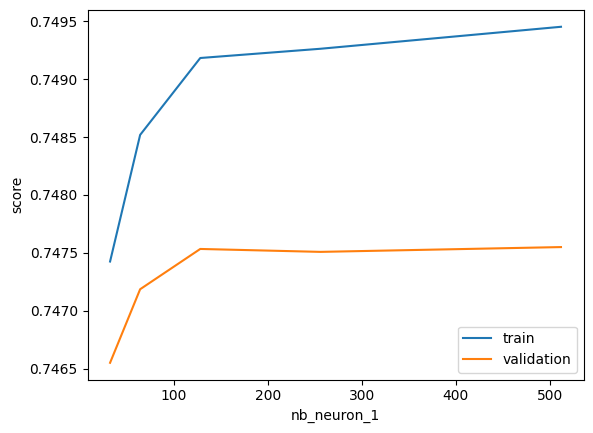

In [93]:
k = [32,64,128,256,512]

train_score, val_score = validation_curve(KerasWrapper(), X_train, y_train_enc,param_name=
                                          'nb_neuron_1', param_range=k, cv=3, scoring=roc_auc_scorer,verbose = 3 ,n_jobs=1)

plt.plot(k, train_score.mean(axis=1), label='train')
plt.plot(k, val_score.mean(axis=1), label='validation')

plt.ylabel('score')
plt.xlabel('nb_neuron_1')
plt.legend()

NB_neuron1 : 128

[CV] END ....nb_neuron_2=32;, score=(train=0.748, test=0.748) total time=13.4min
[CV] END ....nb_neuron_2=64;, score=(train=0.749, test=0.749) total time=13.3min
[CV] END ...nb_neuron_2=128;, score=(train=0.750, test=0.749) total time=14.4min
[CV] END ...nb_neuron_2=256;, score=(train=0.750, test=0.749) total time=14.2min
[CV] END ...nb_neuron_2=512;, score=(train=0.750, test=0.749) total time=16.4min
[CV] END ....nb_neuron_2=32;, score=(train=0.748, test=0.747) total time=13.8min
[CV] END ....nb_neuron_2=64;, score=(train=0.749, test=0.748) total time=13.5min
[CV] END ...nb_neuron_2=128;, score=(train=0.750, test=0.748) total time=14.2min
[CV] END ...nb_neuron_2=256;, score=(train=0.751, test=0.748) total time=14.3min
[CV] END ...nb_neuron_2=512;, score=(train=0.751, test=0.748) total time=15.9min
[CV] END ....nb_neuron_2=32;, score=(train=0.749, test=0.747) total time=13.7min
[CV] END ....nb_neuron_2=64;, score=(train=0.750, test=0.747) total time=13.8min
[CV] END ...nb_neuron_2=128;

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed: 216.6min finished


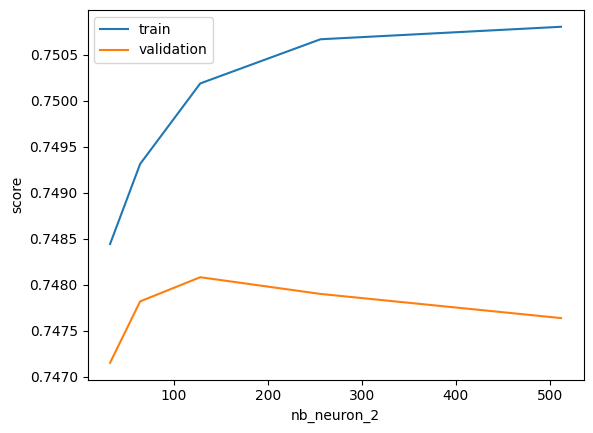

In [94]:
k = [32,64,128,256,512]

train_score, val_score = validation_curve(KerasWrapper(), X_train, y_train_enc,param_name=
                                          'nb_neuron_2', param_range=k, cv=3, scoring=roc_auc_scorer,verbose = 3 ,n_jobs=1)

plt.plot(k, train_score.mean(axis=1), label='train')
plt.plot(k, val_score.mean(axis=1), label='validation')

plt.ylabel('score')
plt.xlabel('nb_neuron_2')
plt.legend()

NB_neuron1 : 128
NB_neuron2 : 128

[CV] END .....dropout_1=0.2;, score=(train=0.748, test=0.748) total time=15.0min
[CV] END .....dropout_1=0.3;, score=(train=0.748, test=0.748) total time=14.1min
[CV] END .....dropout_1=0.4;, score=(train=0.747, test=0.747) total time=14.3min
[CV] END .....dropout_1=0.5;, score=(train=0.746, test=0.747) total time=14.2min
[CV] END .....dropout_1=0.7;, score=(train=0.743, test=0.744) total time=14.6min
[CV] END .....dropout_1=0.2;, score=(train=0.749, test=0.747) total time=14.8min
[CV] END .....dropout_1=0.3;, score=(train=0.748, test=0.747) total time=13.9min
[CV] END .....dropout_1=0.4;, score=(train=0.748, test=0.747) total time=13.9min
[CV] END .....dropout_1=0.5;, score=(train=0.747, test=0.746) total time=14.4min
[CV] END .....dropout_1=0.7;, score=(train=0.745, test=0.744) total time=14.3min
[CV] END .....dropout_1=0.2;, score=(train=0.749, test=0.746) total time=14.1min
[CV] END .....dropout_1=0.3;, score=(train=0.749, test=0.746) total time=14.1min
[CV] END .....dropout_1=0.4;

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed: 216.0min finished


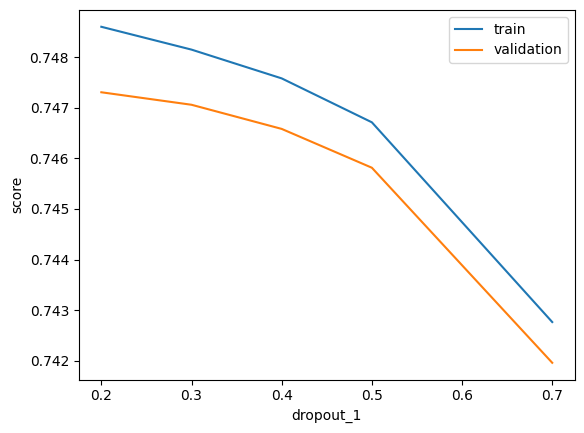

In [95]:
k = [0.2,0.3,0.4,0.5,0.7]

train_score, val_score = validation_curve(KerasWrapper(), X_train, y_train_enc,param_name=
                                          'dropout_1', param_range=k, cv=3, scoring=roc_auc_scorer,verbose = 3 ,n_jobs=1)

plt.plot(k, train_score.mean(axis=1), label='train')
plt.plot(k, val_score.mean(axis=1), label='validation')

plt.ylabel('score')
plt.xlabel('dropout_1')
plt.legend()

NB_neuron1 : 128
NB_neuron2 : 128
dopout_1 : 0.2

[CV] END .....dropout_2=0.2;, score=(train=0.748, test=0.748) total time=13.9min
[CV] END .....dropout_2=0.3;, score=(train=0.748, test=0.749) total time=14.1min
[CV] END .....dropout_2=0.4;, score=(train=0.747, test=0.748) total time=14.1min
[CV] END .....dropout_2=0.5;, score=(train=0.747, test=0.748) total time=14.2min
[CV] END .....dropout_2=0.7;, score=(train=0.746, test=0.747) total time=13.8min
[CV] END .....dropout_2=0.2;, score=(train=0.749, test=0.748) total time=14.7min
[CV] END .....dropout_2=0.3;, score=(train=0.748, test=0.747) total time=14.1min
[CV] END .....dropout_2=0.4;, score=(train=0.749, test=0.747) total time=17.6min
[CV] END .....dropout_2=0.5;, score=(train=0.748, test=0.746) total time=22.7min
[CV] END .....dropout_2=0.7;, score=(train=0.747, test=0.746) total time=15.2min
[CV] END .....dropout_2=0.2;, score=(train=0.750, test=0.747) total time=15.2min
[CV] END .....dropout_2=0.3;, score=(train=0.749, test=0.747) total time=15.2min
[CV] END .....dropout_2=0.4;

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed: 236.4min finished


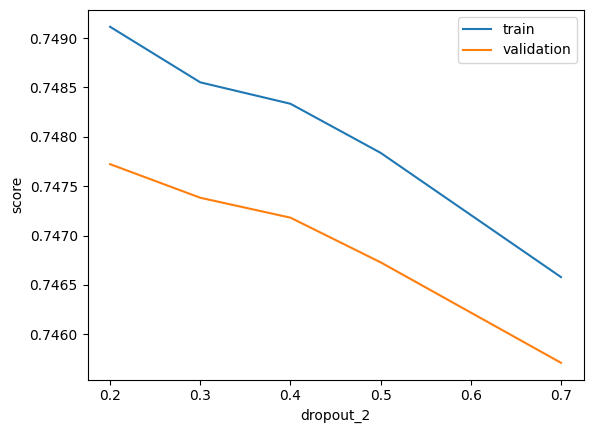

In [96]:
k = [0.2,0.3,0.4,0.5,0.7]

train_score, val_score = validation_curve(KerasWrapper(), X_train, y_train_enc,param_name=
                                          'dropout_2', param_range=k, cv=3, scoring=roc_auc_scorer,verbose = 3 ,n_jobs=1)

plt.plot(k, train_score.mean(axis=1), label='train')
plt.plot(k, val_score.mean(axis=1), label='validation')

plt.ylabel('score')
plt.xlabel('dropout_2')
plt.legend()

NB_neuron1 : 128
NB_neuron2 : 128
dropout_1 : 0.2
dropout_2 : 0.2

In [ ]:
[CV 1/3] END batch_size=256, dropout_1=0.2, epochs=20, lr=0.001, nb_neuron_1=64, nb_neuron_2=32;, score=0.747 total time=10.1min

Epoch 1/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 0.4941 - loss: 1.0861 - val_accuracy: 0.6215 - val_loss: 0.8716
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.5790 - loss: 0.9417 - val_accuracy: 0.6337 - val_loss: 0.8513
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.6024 - loss: 0.9028 - val_accuracy: 0.6348 - val_loss: 0.8467
Epoch 4/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.6155 - loss: 0.8860 - val_accuracy: 0.6355 - val_loss: 0.8441
Epoch 5/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.6214 - loss: 0.8750 - val_accuracy: 0.6356 - val_loss: 0.8430
Epoch 6/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.6242 - loss: 0.8693 - val_accuracy: 0.6358 - val_loss: 0.8423
Epoch 7/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.6271 - loss: 0.8637 - val_accuracy: 0.6362 - val_loss: 0.8417
Epoch 8/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.6281 - loss: 0.8619 - 

[Parallel(n_jobs=1)]: Done  12 out of  12 | elapsed: 103.9min finished


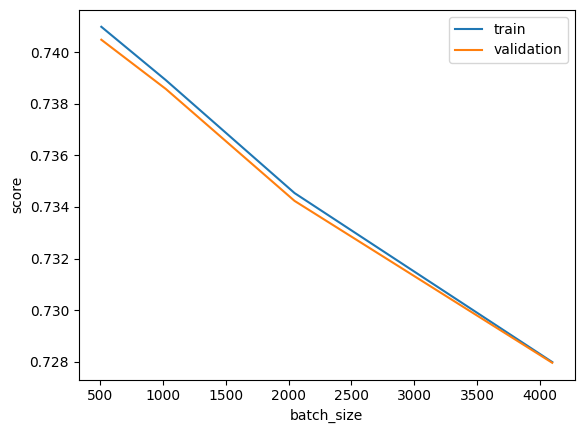

In [130]:
k = [512,1024,2048,4096]
train_score, val_score = validation_curve(KerasWrapper(batch_size=256,dropout_1=0.2,dropout_2=0.3,epochs=20,lr=0.001,nb_neuron_1=64,nb_neuron_2=32), X_train, y_train_enc,param_name=
                                          'batch_size', param_range=k, cv=3, scoring=roc_auc_scorer,verbose = 3 ,n_jobs=1)

plt.plot(k, train_score.mean(axis=1), label='train')
plt.plot(k, val_score.mean(axis=1), label='validation')

plt.ylabel('score')
plt.xlabel('batch_size')
plt.legend()

Le problème de l'accuracy avec un exemple concret
Imagine que tu veux détecter une maladie rare : 95% des gens sont sains, 5% sont malades.
Un modèle stupide qui prédit toujours "sain" aura :

Accuracy = 95% → "excellent !"
AUC-ROC = 0.5 → "complètement nul, équivalent à pile ou face"

Ton modèle n'a rien appris, mais l'accuracy dit que c'est top. C'est le piège.

Est-ce que ton cas est concerné ?
Tout dépend de tes données. Tu as un déséquilibre de classes ?

Si tes classes sont équilibrées (50%/50%) → accuracy et AUC-ROC racontent la même histoire, les deux sont valides
Si tes classes sont déséquilibrées (ex: 80%/20%) → l'AUC-ROC est beaucoup plus fiable


En résumé simple
AccuracyAUC-ROCCe qu'elle mesureBonnes prédictionsCapacité à distinguer les classesProblèmeTrompée par le déséquilibreRobuste au déséquilibreQuand l'utiliserClasses équilibréesToujours, surtout si déséquilibré
Dans ton cas, avec accuracy ≈ 0.63 et AUC ≈ 0.73, les deux métriques confirment que le modèle apprend vraiment quelque chose — c'est rassurant. Mais si tu dois choisir une seule métrique pour comparer des modèles, préfère l'AUC-ROC.

NB_neuron1 : 128
NB_neuron2 : 128
dropout_1 : 0.2
dropout_2 : 0.2
batchside : 512
lr:0.005
epochs:30

In [ ]:
kw_final = KerasWrapper(nb_neuron_1=128,nb_neuron_2=64,dropout_1=0.2,dropout_2=0.3,batch_size=256,lr=0.0005,epochs=20,verbose=2)

In [109]:
model_path = './best_chess_model_makerhub.keras'

In [110]:
# Train the model
kw_final.fit(X_train, y_train_enc)
# loss → erreur sur train

# accuracy → score sur train

# val_loss → erreur sur validation

# val_accuracy → score sur validation

Epoch 1/20
  → val_AUC-ROC: 0.7449
1201/1201 - 56s - 47ms/step - accuracy: 0.6191 - loss: 0.8749 - val_accuracy: 0.6433 - val_loss: 0.8217 - val_auc_roc: 0.7449
Epoch 2/20
  → val_AUC-ROC: 0.7469
1201/1201 - 53s - 44ms/step - accuracy: 0.6357 - loss: 0.8353 - val_accuracy: 0.6440 - val_loss: 0.8194 - val_auc_roc: 0.7469
Epoch 3/20
  → val_AUC-ROC: 0.7477
1201/1201 - 52s - 44ms/step - accuracy: 0.6371 - loss: 0.8300 - val_accuracy: 0.6440 - val_loss: 0.8161 - val_auc_roc: 0.7477
Epoch 4/20
  → val_AUC-ROC: 0.7481
1201/1201 - 82s - 68ms/step - accuracy: 0.6376 - loss: 0.8277 - val_accuracy: 0.6443 - val_loss: 0.8156 - val_auc_roc: 0.7481
Epoch 5/20
  → val_AUC-ROC: 0.7486
1201/1201 - 56s - 46ms/step - accuracy: 0.6379 - loss: 0.8262 - val_accuracy: 0.6436 - val_loss: 0.8135 - val_auc_roc: 0.7486
Epoch 6/20
  → val_AUC-ROC: 0.7486
1201/1201 - 80s - 67ms/step - accuracy: 0.6389 - loss: 0.8247 - val_accuracy: 0.6429 - val_loss: 0.8141 - val_auc_roc: 0.7486
Epoch 7/20
  → val_AUC-ROC: 0.7490

,nb_neuron_1,128
,nb_neuron_2,64
,dropout_1,0.2
,dropout_2,0.3
,lr,0.0005
,epochs,20
,batch_size,256
,verbose,2


In [112]:
X_train

array([[ 2.06618143e-02,  1.81839172e-02, -4.89364888e-01, ...,
         4.02247175e-03, -1.18563477e+00,  9.95454373e-01],
       [-5.64400207e-01, -1.74650367e+00, -4.96629404e-01, ...,
         1.93756458e+00,  7.13596586e-01,  9.95454373e-01],
       [ 1.02395177e+00,  1.07517015e+00, -3.65868119e-01, ...,
        -8.57357691e-02,  1.38482930e-03, -1.00456638e+00],
       ...,
       [-4.75269665e-01, -4.42963422e-01, -4.88638437e-01, ...,
        -5.20764288e-02, -4.73423009e-01, -1.00456638e+00],
       [ 5.96582242e-01,  7.07622019e-01,  9.50462155e-01, ...,
        -1.82973863e-01,  2.38788748e-01, -1.00456638e+00],
       [-1.16462097e-01, -1.05478266e+00,  2.98108631e-01, ...,
         1.53739242e+00,  1.18840442e+00,  9.95454373e-01]],
      shape=(341355, 11))

In [113]:
kw_final.save(model_path)

joblib.dump(st_scaler,"scaler.save")
joblib.dump(le,"labelenc.save")

['labelenc.save']

In [114]:
dftry2.head()

,ELO white,ELO black,Nb_parties_joueur_blanc,Nb_parties_joueur_noir,Type de partie,is_white_advantage,white_winrate_10,black_winrate_10,elo_diff_color_adjusted,form_diff,white_is_stronger
0,3123,2969,0,0,2,1,0.0,0.0,189,0,1
1,3323,3116,532,584,3,1,0.0,0.0,242,0,1
2,3235,2999,409,170,3,1,0.0,0.0,271,0,1
3,3002,3232,171,410,3,1,0.0,0.1,-195,-1,0
4,3230,3004,411,172,3,1,0.2,0.0,261,2,1


In [119]:
if os.path.exists(model_path):
    print('Chargement du modèle existant...')

    # 1. Charger le scaler et le label encoder
    sc = joblib.load("scaler.save")
    le = joblib.load("labelenc.save")

    # 2. Reconstruire le wrapper et injecter le modèle keras
    kw_final = KerasWrapper()
    kw_final.model_ = load_model(model_path)
    kw_final.classes_ = le.classes_  # nécessaire pour predict_proba
else:
    print('Training...')
    sc = StandardScaler()                          # nom cohérent partout
    X_train_scaled = sc.fit_transform(X_train)     # fit uniquement sur train

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)

    kw_final = KerasWrapper(
        nb_neuron_1=128, nb_neuron_2=64,
        dropout_1=0.2,   dropout_2=0.3,
        batch_size=512,  lr=0.0005, epochs=20
    )
    kw_final.fit(X_train_scaled, y_train_enc)
    kw_final.save(model_path)

    joblib.dump(sc, "scaler.save")   # même variable : sc
    joblib.dump(le, "labelenc.save")

X_new = [[3100, 2900, 100, 100, 2,1, 0.4, 0.2, 235, 2, 1]]

# transform seulement — jamais fit_transform sur de nouvelles données
X_new_scaled = sc.transform(X_new)

# Probabilités par classe
probas = kw_final.predict_proba(X_new_scaled)
print("Probabilités :", probas)
# → [[0.12, 0.75, 0.13]]  (exemple)

# Classe prédite (encodée)
pred_enc = kw_final.predict(X_new_scaled)
print("Classe encodée :", pred_enc)
# → [1]

# Classe lisible (label original)
pred_label = le.inverse_transform(pred_enc)[0]

labels = {'Blanc': "Blanc Win", 'Draw': "Draw", 'Noir': "Noir Win"}
label = labels.get(pred_label, "Inconnu")
indice_confiance = probas[0][pred_enc[0]]
print("Classe prédite :", label,"\nIndice de confiance",round(100*indice_confiance,2),"%")



Chargement du modèle existant...
Probabilités : [[0.7208811  0.11526936 0.16384947]]
Classe encodée : [0]
Classe prédite : Blanc Win 
Indice de confiance 72.09 %


c:\Users\rasse\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predict